# TSAC EEG Sleep-Stage Classification  

**Group Project (Due May 17, 2025)**  
**Course:** Time Series Analysis & Classification (TSAC)  
**Team:**

    member 01:Messahel hibetallah

    member 02:BOUDJELAL Mounir

    member 03:GHENAM Douaa

    member 04:BELKEBIR Mustapha
  
---

### What is EEG?  
Electroencephalography (EEG) is a non-invasive technique that records the brain’s electrical activity via small sensors (electrodes) placed on the scalp.  Neurons communicate by tiny voltage changes; when many neurons fire together, electrodes detect rhythmic waveforms reflecting different brain states.

- **Why EEG?** It provides millisecond-level resolution of brain dynamics, making it ideal for studying rapid transitions in mental states such as sleep stages.  
- **How it’s recorded:**  Standard caps hold 16–32 electrodes; signals are amplified (from microvolts to measurable voltages), filtered (e.g. 0.5–40 Hz), and digitized into time-series samples.  

---

### Sleep Stages & Their EEG Signatures  
Human sleep cycles through five stages, each with characteristic EEG patterns:

| Stage Code | Name                  | EEG Signature                                          |
|------------|-----------------------|--------------------------------------------------------|
| **0**      | Wake                  | Low-amplitude, mixed-frequency (“desynchronized”)      |
| **1 (E1)** | NREM Stage 1 (Light)  | Emergence of theta waves (4–8 Hz), slow eye movements  |
| **2 (E2)** | NREM Stage 2          | Sleep spindles (12–14 Hz bursts) and K-complexes       |
| **3 (E3)** | NREM Stage 3 (Deep)   | High-amplitude, slow delta waves (< 4 Hz)              |
| **4**      | REM (Dreaming)        | Low-amplitude, mixed-frequency like wake + rapid eyes  |

Sleep normally cycles through these stages every ~90 minutes.  Accurately identifying (scoring) each 30 s or 1 s epoch is crucial in diagnosing disorders (e.g., sleep apnea, insomnia) and in sleep research.  

---

### Why Classify EEG Sleep Stages Automatically?  
- **Clinical efficiency:** Manual scoring by experts is time-consuming and subject to variability.  
- **Research insights:** Large-scale sleep studies generate massive EEG recordings—automated methods enable scalable analysis.  
- **Real-time applications:** Smart sleep trackers and brain-computer interfaces rely on fast, accurate stage detection.  



In this project, each row of our CzSV is one EEG epoch labelled with its sleep-stage code.  Our goal is to train models that can learn the unique waveform patterns of each stage and predict unlabeled epochs with high accuracy.




## 0. Install Required Packages

We rely on:

- **pandas**, **numpy**: data manipulation  
- **matplotlib**: plotting and visualization  
- **scikit-learn**: preprocessing, classical ML, evaluation, cross-validation  
- **imbalanced-learn**: SMOTE for oversampling minority classes  
- **TensorFlow/Keras**: building and training the 1D-CNN  
- **seaborn**: enhanced statistical plotting  

These libraries cover data I/O, EDA, modeling, and advanced deep learning.

In [ ]:
!pip install python_speech_features
!pip install xgboost

In [ ]:
!pip install imbalanced-learn
!pip install matplotlib
!pip install seaborn
!pip install tensorflow
!pip install keras
!pip install pandas
!pip install numpy
!pip install scikit-learn

## 1. Imports & Random Seed

Import all modules and set seeds for reproducibility


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split


from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 2. Data Loading & Inspection

**Steps:**
1. Read CSVs.
2. Extract `y_train` from column 0 (sleep-stage codes 0–4).  
3. Extract `X_train` from columns (EEG time-series).  
4. Load `X_test` similarly.


Below we also print shapes and show the first few rows to confirm everything loaded correctly.

In [ ]:
train_df = pd.read_csv('Sleep Train 5000.csv', header=None)
test_df  = pd.read_csv('Sleep Test 1000.csv', header=None)

train_df.rename(columns={0: 'class'}, inplace=True)
train_df.head()

test_df.rename(columns={0: 'class'}, inplace=True)
test_df.head()

y_train = train_df.iloc[:, 0].astype(int)

X_train = train_df.iloc[:, 1:].values

X_test  = test_df.values

print(f"X_train shape: {X_train.shape}   (epochs × time-steps)")
print(f"y_train shape: {y_train.shape}   (labels)")
print(f"X_test  shape: {X_test.shape}   (epochs × time-steps)")

display(train_df.head(3).style.set_caption("First 3 rows: col 0=label, cols 1–178=EEG series"))


X_train shape: (4999, 178)   (epochs × time-steps)
y_train shape: (4999,)   (labels)
X_test  shape: (1000, 178)   (epochs × time-steps)


,class,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178
0,0,-1.608303,-13.170696,-8.997802,1.347497,5.259585,-1.521367,2.651526,4.651038,3.781685,-1.521367,1.173626,-2.651526,-0.738950,5.520391,2.999267,15.083272,13.170696,10.562637,-11.345055,1.695238,-2.999267,-4.303297,-7.346032,-0.652015,-4.129426,-9.171673,2.651526,19.777779,7.259097,13.605372,6.042003,8.128449,-1.086691,8.910867,0.652015,11.258120,2.390720,6.042003,10.562637,19.516972,11.345055,17.082785,7.606838,13.866179,0.565079,-11.258120,-6.650549,-5.781197,-0.391209,10.475702,9.345543,-6.215873,3.347008,3.520879,-0.304274,3.520879,7.432967,-7.606838,-14.387790,-11.866667,0.130403,3.694750,2.303785,-1.695238,4.390232,-2.216850,0.217338,11.171185,10.649572,7.259097,-5.433455,-17.343590,-14.996337,-0.999756,1.521367,7.259097,0.304274,2.129914,8.302320,6.476679,8.302320,6.389744,4.390232,-6.563614,-15.952625,-4.564103,-1.434432,2.390720,12.822955,18.995360,-0.043468,5.172649,12.475214,5.259585,-4.564103,-8.823932,-12.127473,-35.773872,-27.080341,-6.998291,7.606838,9.432479,4.651038,14.735531,11.084250,9.258608,11.431991,-6.824420,-1.608303,-13.344566,-6.215873,-10.562637,-4.564103,-8.128449,-3.347008,-6.215873,-8.650061,-2.303785,6.824420,9.432479,13.344566,2.564591,-6.128938,-5.346520,3.781685,8.563126,4.998779,1.173626,0.825885,4.216361,11.171185,9.867155,15.517949,-4.737973,-3.433944,-7.519902,4.477167,-3.607814,1.695238,-3.607814,-9.867155,-14.996337,-13.170696,-4.998779,-5.781197,-12.649084,-1.869109,-16.474237,-1.695238,-8.650061,4.824908,-1.695238,-1.434432,-7.259097,-9.432479,0.043468,-10.562637,2.390720,-12.996825,-16.735043,-18.126007,-16.474237,1.782173,-3.086203,7.346032,1.956044,0.912821,-3.520879,-8.041514,-6.563614,-4.998779,-5.346520,-6.389744,-11.171185,-2.390720,1.086691,6.911355,6.128938
1,0,-2.825397,2.390720,3.955555,-4.216361,2.477656,2.129914,3.955555,-5.172649,5.694261,1.608303,-4.216361,-7.259097,-0.478144,8.389256,-5.259585,4.824908,9.345543,14.648596,15.517949,4.737973,-0.391209,5.694261,-3.520879,-1.869109,4.129426,2.912332,-0.565079,11.084250,6.476679,10.475702,8.389256,2.216850,3.781685,7.606838,1.521367,6.042003,8.215385,-1.260562,-2.738462,-7.432967,7.259097,2.912332,12.736019,0.912821,0.391209,-15.778754,-14.474726,-9.606349,-9.258608,-0.130403,-12.214408,2.912332,-10.214896,-5.781197,-9.171673,-19.777779,-8.302320,-4.129426,-9.258608,5.259585,1.608303,7.780708,11.779732,5.694261,-3.433944,7.172161,-1.782173,-3.520879,-12.475214,-7.606838,-5.868132,2.738462,9.258608,22.211966,23.429060,12.736019,8.389256,9.780220,5.781197,1.695238,-7.954579,-8.476191,-6.389744,16.648108,6.563614,8.563126,1.956044,1.608303,-12.127473,-9.693284,-8.650061,-6.476679,-11.171185,-7.867643,-18.995360,2.999267,0.652015,-2.564591,-2.390720,-6.824420,-4.824908,-6.824420,-8.563126,-12.040537,-8.302320,-6.389744,-1.521367,-2.651526,-4.390232,-0.478144,8.736997,-4.824908,-7.519902,-0.130403,-5.868132,-4.216361,-3.433944,-1.260562,8.041514,5.085714,-3.955555,2.912332,2.738462,6.737485,-3.520879,8.823932,-1.086691,1.695238,-1.086691,-0.912821,-4.998779,3.868620,-7.693773,-2.651526,-9.954090,-4.042491,-6.824420,-8.128449,-4.042491,4.824908,-5.781197,5.259585,-5.694261,10.127961,-9.084738,-3.781685,-3.607814,-3.694750,6.476679,3.086203,4.998779,1.347497,-6.476679,-3.433944,-10.127961,-7.606838,-11.779732,-9.780220,-0.565079,3.955555,-1.956044,-0.912821,4.564103,0.217338,4.651038,-5.868132,-4.651038,6.824420,4.129426,7.085226,

## 3. Exploratory Data Analysis (EDA)


**Goals:**
1. **Class distribution** – visualize how many epochs belong to each sleep stage.  
2. **Waveform inspection** – plot one EEG epoch per class to see characteristic shapes.  
3. **Feature distributions** – use box plots to see spread/skew across time-steps.  
4. **Outlier detection** – scatter min vs. max per epoch to flag extreme values.



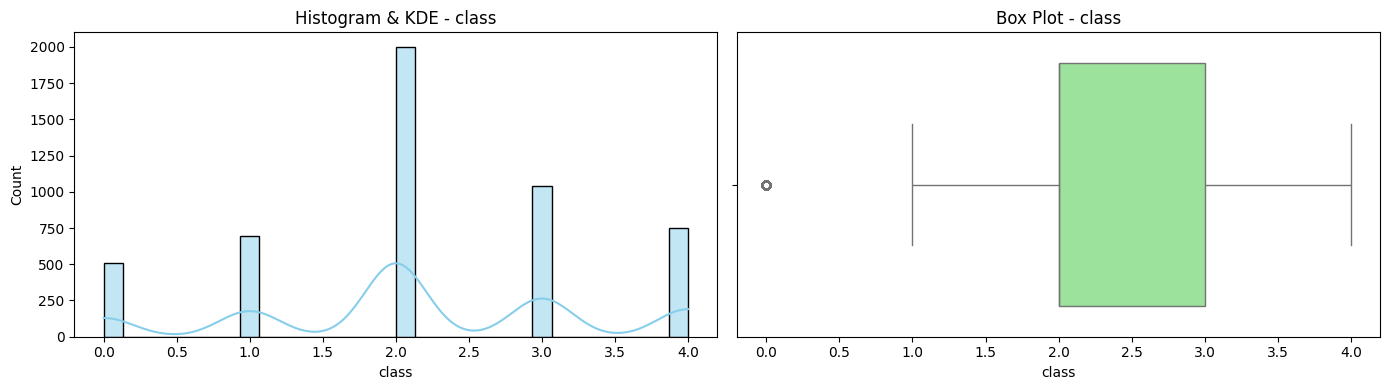

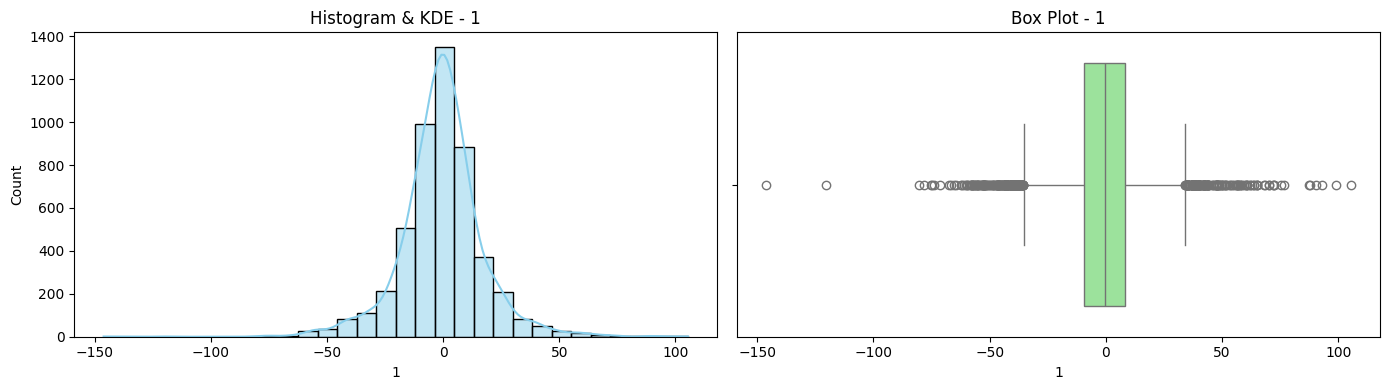

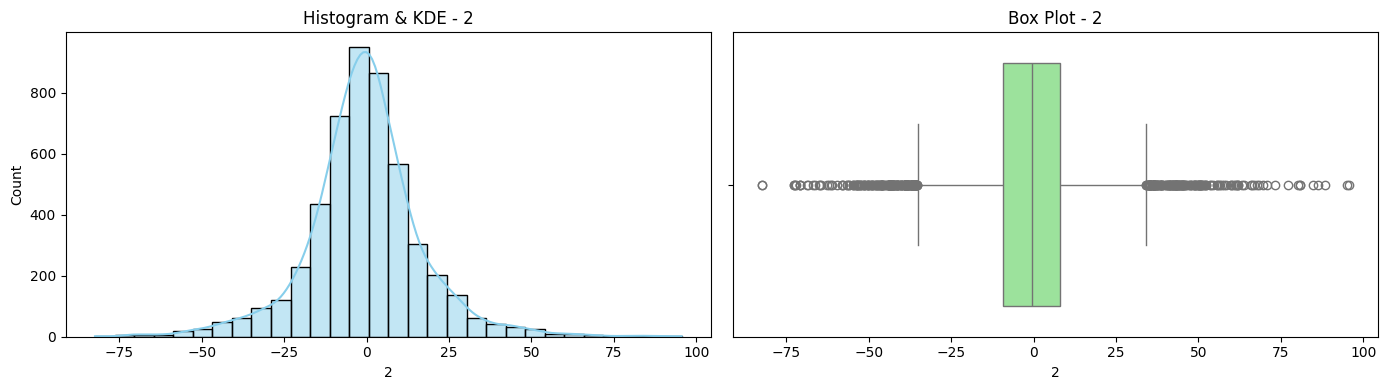

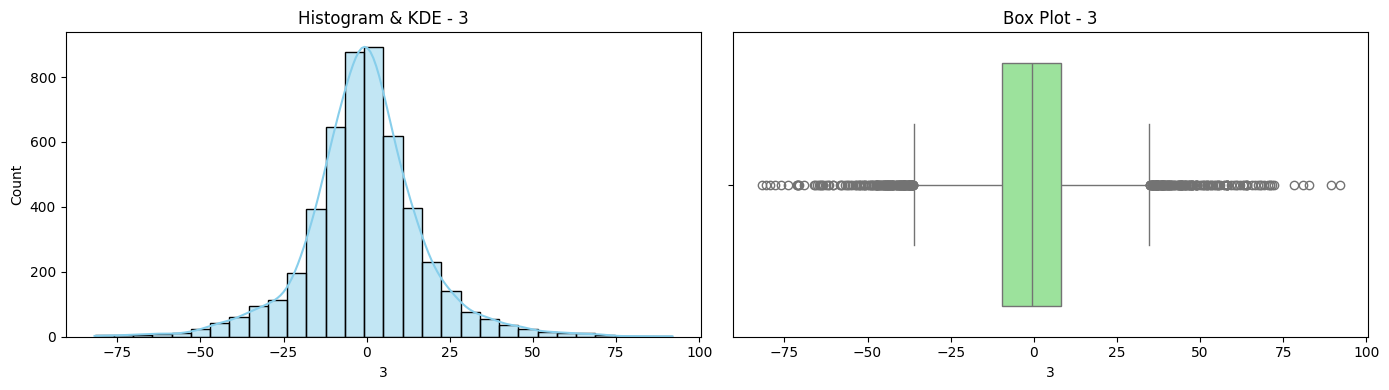

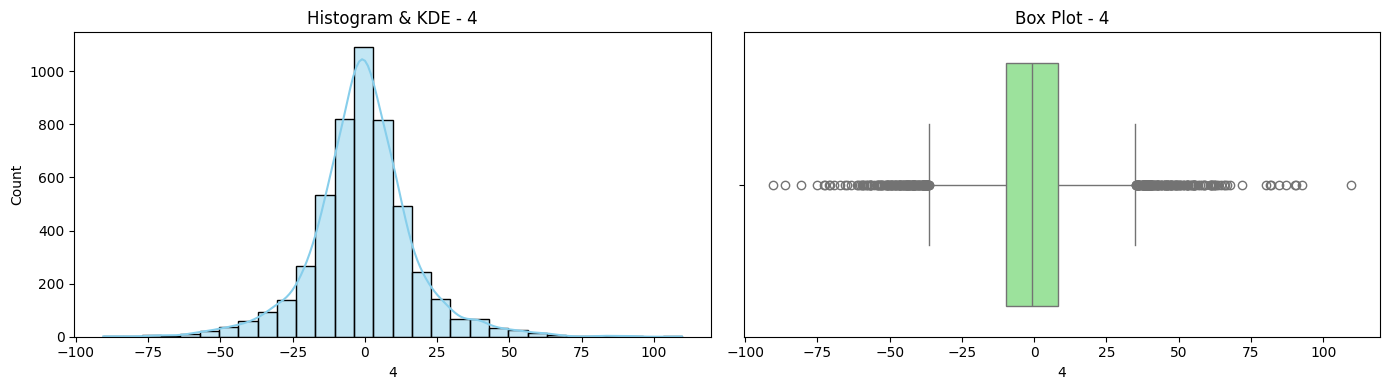

In [ ]:
def plot_feature_distributions(df, num_features=5):
    features = df.select_dtypes(include=['float64', 'int64']).columns[:num_features]

    for feature in features:
        plt.figure(figsize=(14, 4))

        # Histogram + KDE
        plt.subplot(1, 2, 1)
        sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
        plt.title(f'Histogram & KDE - {feature}')

        # Box plot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[feature], color='lightgreen')
        plt.title(f'Box Plot - {feature}')

        plt.tight_layout()
        plt.show()


plot_feature_distributions(train_df)


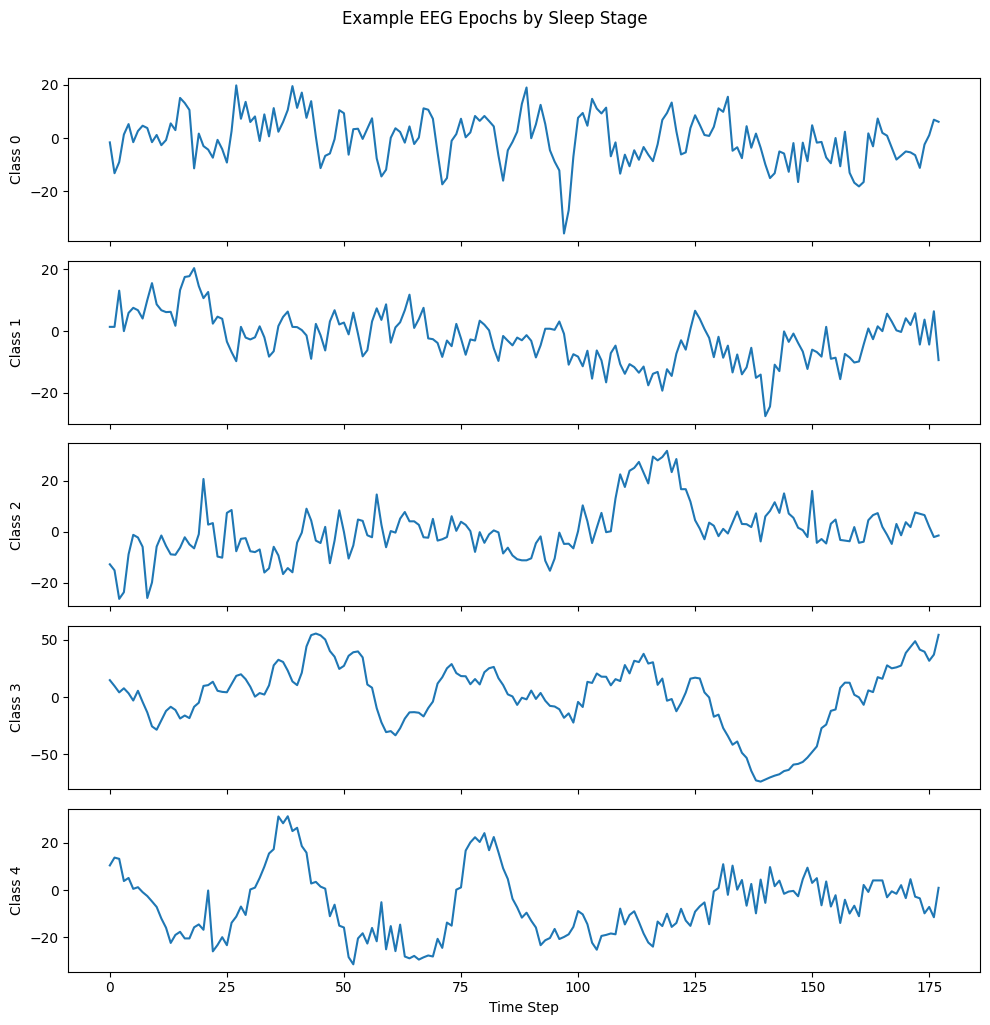

In [ ]:
# Sample waveforms for classes 0–4
classes = list(range(5))
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
for i, cls in enumerate(classes):
    idxs = np.where(y_train == cls)[0]
    if len(idxs) > 0:
        axes[i].plot(X_train[idxs[0], :])
    else:
        axes[i].text(0.5, 0.5, f'No samples for class {cls}', ha='center')
    axes[i].set_ylabel(f'Class {cls}')
axes[-1].set_xlabel('Time Step')
plt.suptitle('Example EEG Epochs by Sleep Stage', y=1.02)
plt.tight_layout()
plt.show()


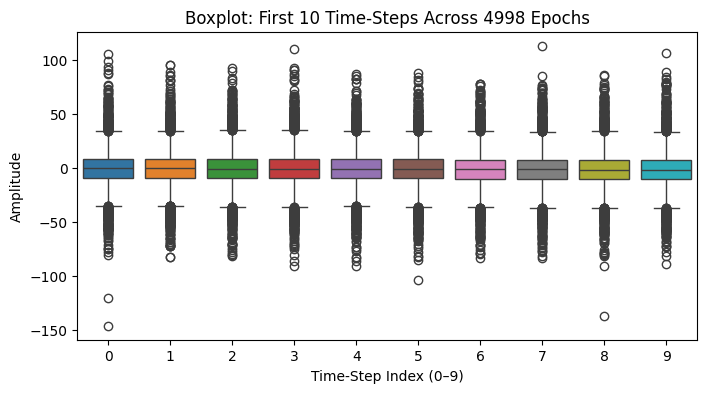

In [ ]:
# Box plot (first 10 of data)
ts_sample = X_train[np.random.choice(len(X_train), 4998, replace=False), :10]
plt.figure(figsize=(8,4))
sns.boxplot(data=ts_sample)
plt.xlabel('Time-Step Index (0–9)'); plt.ylabel('Amplitude')
plt.title('Boxplot: First 10 Time-Steps Across 4998 Epochs')
plt.show()


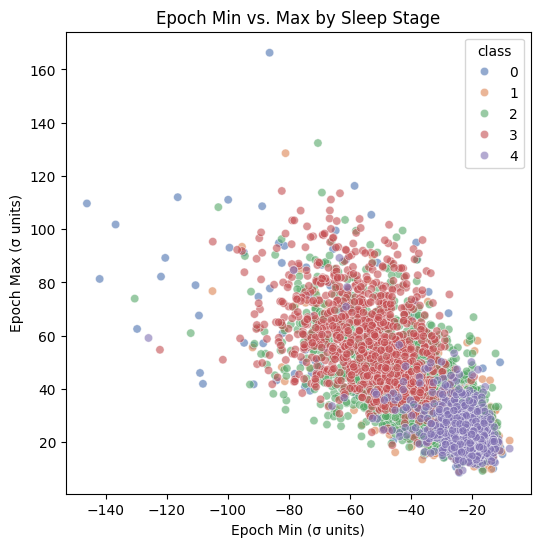

In [ ]:
# Scatter of epoch min vs max to highlight outliers
epoch_max = X_train.max(axis=1)
epoch_min = X_train.min(axis=1)
plt.figure(figsize=(6,6))
sns.scatterplot(x=epoch_min, y=epoch_max, hue=y_train, palette='deep', alpha=0.6)
plt.xlabel('Epoch Min (σ units)'); plt.ylabel('Epoch Max (σ units)')
plt.title('Epoch Min vs. Max by Sleep Stage')
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

def preprocess_data(df, target_column=None):
    report = []

    # 1. Separate features and target
    if target_column:
        X = df.drop(columns=[target_column])
        y = df[target_column]
    else:
        X = df.copy()
        y = None

    # 2. Check for missing values
    missing_info = X.isnull().sum()
    missing_cols = missing_info[missing_info > 0].index.tolist()
    if missing_cols:
        report.append(f"Missing values in columns: {missing_cols}")
        X = X.fillna(X.median())  # or use dropna() to remove rows
    else:
        report.append("No missing values detected.")

    # 3. Detect constant features
    constant_cols = [col for col in X.columns if X[col].nunique() == 1]
    if constant_cols:
        report.append(f"Constant features detected and removed: {constant_cols}")
        X.drop(columns=constant_cols, inplace=True)

    # 4. Skewness and outlier info
    skewness = X.apply(lambda x: skew(x.dropna()))
    skewed_features = skewness[abs(skewness) > 1].index.tolist()
    normal_features = skewness[abs(skewness) <= 1].index.tolist()
    report.append(f"Right/left skewed columns (|skew| > 1): {skewed_features}")
    report.append(f"Approximately normal columns: {normal_features}")

    # 5. Outlier detection (simple IQR method)
    outlier_flags = {}
    for col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((X[col] < (Q1 - 1.5 * IQR)) | (X[col] > (Q3 + 1.5 * IQR))).sum()
        outlier_flags[col] = outliers
    outlier_features = [col for col, count in outlier_flags.items() if count > 0]
    report.append(f"columns containing outliers: {outlier_features}")

    # 6. Standardization
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    if target_column:
        X_scaled[target_column] = y.values  # append target back

    return X_scaled, report


In [ ]:
clean_df, summary = preprocess_data(train_df, target_column='class')

for item in summary:
    print(item)

No missing values detected.
Right/left skewed columns (|skew| > 1): []
Approximately normal columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178]
columns containing outliers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,

In [ ]:
from scipy.stats import skew
import warnings
warnings.filterwarnings("ignore")

report = []

numeric_cols = train_df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    feature_data = train_df[col].dropna()
    sk = skew(feature_data)
    q1 = feature_data.quantile(0.25)
    q3 = feature_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((feature_data < lower_bound) | (feature_data > upper_bound)).sum()

    # Determine skewness type
    if abs(sk) < 0.5:
        skew_type = "Normal"
    elif sk > 0:
        skew_type = "Right-skewed"
    else:
        skew_type = "Left-skewed"

    report.append({
        'Feature': col,
        'Skewness': round(sk, 2),
        'Distribution': skew_type,
        'Outliers': outliers,
        'Outlier %': round(outliers / len(feature_data) * 100, 2)
    })

print(pd.DataFrame(report).set_index('Feature'))


         Skewness Distribution  Outliers  Outlier %
Feature                                            
class       -0.14       Normal       511      10.22
1           -0.02       Normal       328       6.56
2            0.12       Normal       328       6.56
3            0.09       Normal       312       6.24
4            0.19       Normal       312       6.24
...           ...          ...       ...        ...
174          0.14       Normal       306       6.12
175          0.14       Normal       302       6.04
176          0.20       Normal       272       5.44
177          0.11       Normal       292       5.84
178          0.12       Normal       297       5.94

[179 rows x 4 columns]


# 3.Feature enginnering and selection

Before feeding data into our models, we transform and reduce the raw time-series into informative, compact representations:

#### **1.Z-score normalization (per epoch)**

- Subtract each epoch’s mean and divide by its standard deviation.

- Ensures every epoch has zero mean and unit variance, so models learn waveform shape rather than absolute amplitude.

#### **2.Spectrogram Extraction for All Epochs**

- Break each normalized 1D epoch into overlapping windows and compute its short-time Fourier transform.

- Converts our signal into a 2D time–frequency “image” (frequency bins × time bins), capturing how power distributes across frequencies over time.

- Provides the CNN with both temporal and spectral features, which are often more discriminative than raw waveforms.

#### **3.Scaling and Normalization**

- Apply a logarithm to each spectrogram value (e.g. log(Sxx+ε)) to compress the dynamic range of the power spectrum.

- Subtract the mean and divide by the standard deviation per spectrogram, so each one has zero mean and unit variance.

- Highlights subtle frequency components while keeping the overall contrast consistent across epochs.

#### **4.Visualization**

- Plot an example log-normalized spectrogram using a pseudocolor mesh (e.g. plt.pcolormesh) with frequency on the y-axis and time on the x-axis.

- Add a colorbar to map pixel intensity back to normalized log-power.

- Use this visual check to confirm that your preprocessing pipeline yields clear, well-scaled time–frequency patterns before training.

#### **Z-score normalization (per epoch)**

- Each epoch (trial) is centered and scaled to unit variance so that the network focuses on waveform shape rather than absolute amplitude.

In [ ]:
def z_score_per_epoch(X):
    means = X.mean(axis=1, keepdims=True)
    stds = X.std(axis=1, keepdims=True)
    stds[stds == 0] = 1
    return (X - means) / stds

X_train_norm = z_score_per_epoch(X_train)

In [ ]:
X_train_norm.shape

(4999, 178)

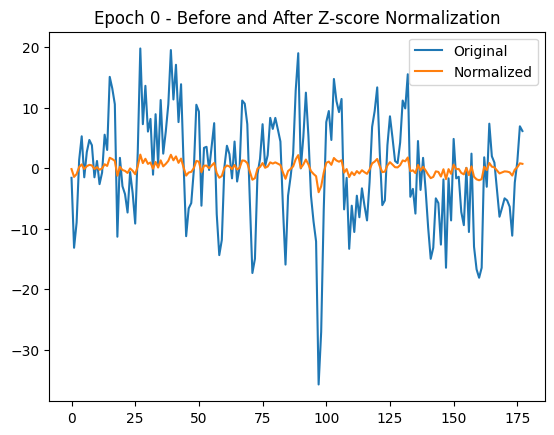

In [ ]:
plt.plot(X_train[0], label="Original")
plt.plot(X_train_norm[0], label="Normalized")
plt.legend()
plt.title("Epoch 0 - Before and After Z-score Normalization")
plt.show()

In [ ]:
print("Mean after normalization :", np.mean(X_train_norm[0]))
print("Std after normalization :", np.std(X_train_norm[0]))

Mean after normalization : -1.995906561123877e-17
Std after normalization : 0.9999999999999999


#### **Spectrogram Extraction for All Epochs**  
    

- Convert each 1D epoch into a 2D time-frequency representation.

In [ ]:
from scipy.signal import spectrogram

In [ ]:
Sxx_list = []
for epoch in X_train_norm:
    f, t, Sxx = spectrogram(epoch, fs=100, nperseg=32 ,noverlap=24, window='hamming')
    Sxx_list.append(Sxx)

spectrograms = np.array(Sxx_list)
spectrograms = spectrograms[..., np.newaxis]

#### **Log Scaling and Normalization**  

- Compress the dynamic range and then z-score normalize across each spectrogram.

In [ ]:
Sxx_log = np.log10(spectrograms + 1e-10)
mean = np.mean(Sxx_log, axis=(1,2,3), keepdims=True)
std = np.std(Sxx_log, axis=(1,2,3), keepdims=True)
Sxx_norm_log = (Sxx_log - mean) / (std + 1e-8)

####  **visualization**

In [ ]:
n_epochs, n_freq_bins, n_time_bins, n_channels = Sxx_norm_log.shape
print(f"Spectrogram shape: ({n_freq_bins}, {n_time_bins})")

Spectrogram shape: (17, 19)


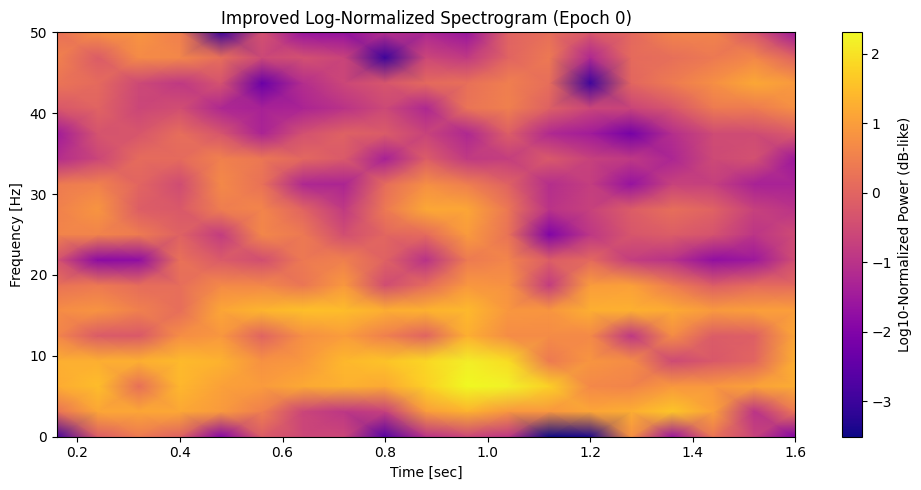

In [ ]:
plt.figure(figsize=(10, 5))
plt.pcolormesh(t, f, Sxx_norm_log[0, :, :, 0], shading='gouraud', cmap='plasma')
plt.colorbar(label='Log10-Normalized Power (dB-like)')
plt.title("Improved Log-Normalized Spectrogram (Epoch 0)")
plt.xlabel("Time [sec]")
plt.ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

# 4. model building :

In [ ]:
n_epochs, n_freq_bins, n_time_bins, n_channels = Sxx_norm_log.shape

print("Number of examples (epochs):", n_epochs)
print("Freq bins:", n_freq_bins)
print("Time bins:", n_time_bins)
print("Channels:", n_channels)

Number of examples (epochs): 4999
Freq bins: 17
Time bins: 19
Channels: 1


### We split the data

In [ ]:
X_train_ml = X_train_norm.reshape(n_epochs, -1)  # Shape: (5000, 178)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=10)

In [ ]:
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_ml, y_train, test_size=0.3, random_state=42)


## KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_split, y_train_split)

KNeighborsClassifier(metric='euclidean')

In [ ]:
y_pred_model = knn.predict(X_test_split)

Accuracy: 0.362

Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.26      0.30       166
           1       0.25      0.10      0.14       221
           2       0.43      0.45      0.44       583
           3       0.31      0.67      0.42       306
           4       0.35      0.06      0.11       224

    accuracy                           0.36      1500
   macro avg       0.34      0.31      0.28      1500
weighted avg       0.36      0.36      0.33      1500



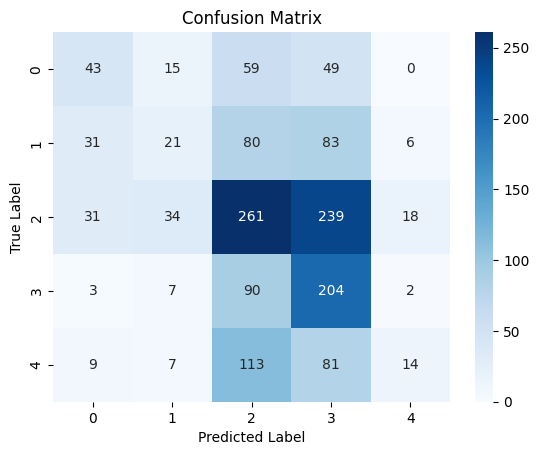

In [ ]:
print("Accuracy:", accuracy_score(y_test_split, y_pred_model))
print("\nClassification Report:\n", classification_report(y_test_split, y_pred_model))
cm = confusion_matrix(y_test_split, y_pred_model)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

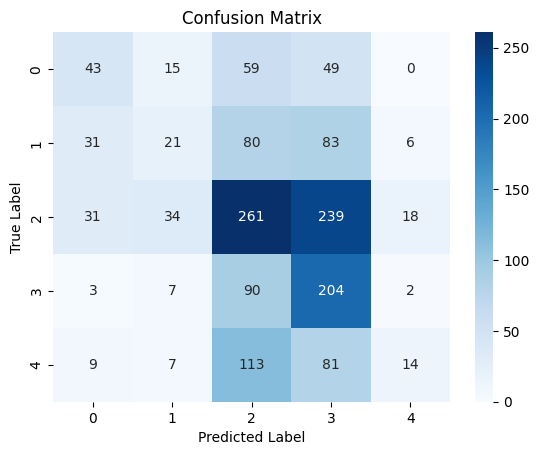

In [ ]:
cm = confusion_matrix(y_test_split, y_pred_model)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

We apply some hyper-parameters tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# 1. Build a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. Define hyperparameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

# 3. Grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_split, y_train_split)

# 4. Best parameters and model
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# 5. Test set evaluation
best_tuned_model = grid_search.best_estimator_
y_pred_best_model = best_tuned_model.predict(X_test_split)

from sklearn.metrics import classification_report
print("\nClassification Report:\n", classification_report(y_test_split, y_pred_best_model))


Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Best Cross-Validation Score: 0.3732519926425506

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.18      0.25       166
           1       0.22      0.05      0.08       221
           2       0.44      0.50      0.47       583
           3       0.30      0.67      0.41       306
           4       0.29      0.04      0.06       224

    accuracy                           0.36      1500
   macro avg       0.34      0.29      0.26      1500
weighted avg       0.35      0.36      0.32      1500



Clearly KNN is not the best model to be used here with the original dataset, so we go to another approach. We can make use of the Spectrogram's data.

In [ ]:
X_flat = Sxx_norm_log.reshape((n_epochs, -1))

# y_train = your labels for the 4999 epochs
X_train, X_test, y_train_split, y_test_split = train_test_split(X_flat, y_train, test_size=0.2, random_state=42)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train_split)

# Predict & evaluate
y_pred = knn.predict(X_test)
print(classification_report(y_test_split, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.24      0.36       111
           1       0.41      0.13      0.20       147
           2       0.44      0.60      0.50       389
           3       0.38      0.69      0.49       203
           4       0.31      0.03      0.06       150

    accuracy                           0.42      1000
   macro avg       0.45      0.34      0.32      1000
weighted avg       0.44      0.42      0.37      1000



### Using wavelet

As we are aware of, The Wavelet Transform is a powerful mathematical technique used to decompose a signal (such as audio, image, or time-series data) into components at different frequencies and time (or spatial) locations. It is widely used in signal processing, image compression, noise reduction, and feature extraction.

In [ ]:
import pywt

def extract_wpd_features(signal, wavelet='db4', level=3):
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, maxlevel=level)
    nodes = wp.get_level(level, order='freq')
    features = []

    for node in nodes:
        coeffs = node.data
        features.extend([
            np.mean(coeffs),
            np.std(coeffs),
            np.median(coeffs),
            np.sum(np.square(coeffs)),  # energy
        ])
    return features


In [ ]:
X_wpd_features = [extract_wpd_features(epoch) for epoch in X_train]
X_wpd_features = np.array(X_wpd_features)


In [ ]:
X_train_wpd, X_test_wpd, y_train_split, y_test_split = train_test_split(X_wpd_features, y_train, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_wpd, y_train_split)

y_pred = knn.predict(X_test_wpd)
print(classification_report(y_test_split, y_pred))


              precision    recall  f1-score   support

           0       0.50      0.48      0.49       111
           1       0.59      0.33      0.43       147
           2       0.57      0.68      0.62       389
           3       0.69      0.73      0.71       203
           4       0.53      0.47      0.50       150

    accuracy                           0.58      1000
   macro avg       0.58      0.54      0.55      1000
weighted avg       0.58      0.58      0.58      1000



## Results KNN:
After evaluating multiple KNN models using different feature extraction strategies, the following summarizes the classification performance for sleep stage recognition:

##1. Basic KNN with Raw Time-Series Data
- Directly applied on normalized EEG data (no transformation)

- Accuracy: 0.36

- Classification Report:

- Stronger performance on NREM Stage 2 (class 2) and NREM Stage 3 (class 3)

- Poor generalization on NREM Stage 1 (class 1) and REM (class 4) stages

- Shows that raw features are insufficiently discriminative for complex temporal patterns in EEG

##2. KNN with Sxx Spectrogram Features
- Used 2D spectrograms converted to flattened feature vectors

- Accuracy: 0.42

- Classification Report:

- Significant improvement on NREM Stage 2 (class 2) and Stage 3 (class 3)

- Wake (class 0) shows better precision but low recall, suggesting class imbalance sensitivity

- Still limited in distinguishing Stage 1 and REM

- Spectrograms help capture time-frequency patterns, boosting KNN performance moderately

##3. KNN with Spectrogram Features + Wavelet Transform
- Applied Wavelet Transform (e.g., DWT or WPD) to spectrograms for enhanced time-frequency decomposition

- Extracted statistical features (e.g., mean, std, energy) from wavelet coefficients

- Accuracy: 0.58

- Classification Report:

- High precision and recall for NREM Stage 2, Stage 3, and noticeable gains on REM (class 4)

- Wake (class 0) and Stage 1 also show more balanced performance

- Macro and weighted averages both improved to ~0.55–0.58

- Combining wavelet-based features with spectrograms provided a more robust feature representation, leading to the best KNN results

# CNN-LSTM hybrid

The CNN-LSTM hybrid model is ideal for tasks like EEG classification since we want to extract spatial patterns (via CNN) and capture temporal dynamics (via LSTM).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Reshape, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Ensure labels are categorical
y_cat = to_categorical(y_train)

# Split dataset
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    Sxx_norm_log, y_cat, test_size=0.2, random_state=42
)

# CNN-LSTM Model
model = Sequential()

# CNN part
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(17, 19, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# Prepare for LSTM: reshape to (batch_size, time_steps, features)
model.add(Reshape((model.output_shape[1] * model.output_shape[2], model.output_shape[3])))

# LSTM part
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))

# Output
model.add(Dense(y_cat.shape[1], activation='softmax'))

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train_split, y_train_split, epochs=20, batch_size=64, validation_data=(X_test_split, y_test_split))


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.3525 - loss: 1.5216 - val_accuracy: 0.2450 - val_loss: 1.4665
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.4469 - loss: 1.2406 - val_accuracy: 0.2140 - val_loss: 1.7056
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.4952 - loss: 1.1482 - val_accuracy: 0.2320 - val_loss: 1.7473
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.5315 - loss: 1.0983 - val_accuracy: 0.3840 - val_loss: 1.2916
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.5632 - loss: 1.0532 - val_accuracy: 0.4720 - val_loss: 1.1865
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.5827 - loss: 1.0028 - val_accuracy: 0.5370 - val_loss: 1.0608
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.5805 - loss: 0.9974 - val_accuracy: 0.5790 - val_loss: 1.0106
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5883 - loss: 0.9687 - val_accuracy: 0.6080 -

In [ ]:
loss, acc = model.evaluate(X_test_split, y_test_split)
print(f"Test Accuracy: {acc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6391 - loss: 0.9009
Test Accuracy: 0.6620


**Enhancing the CNN-LSTM**, using an **Attention layer** that allow the architecture to dynamically focus on the most relevant temporal or spatial features when making predictions. In a standard CNN-LSTM pipeline for EEG or time-series classification, the CNN extracts local patterns from input data (e.g., spatial or frequency-domain features), while the LSTM captures long-term dependencies over time. However, LSTMs tend to treat all time steps with equal importance unless explicitly guided otherwise. By integrating an Attention mechanism, the model learns to assign different weights to different time steps or feature vectors, effectively prioritizing critical moments or regions in the signal that are more informative for the target task. This not only improves interpretability—by highlighting what the model is "looking at"—but also enhances classification accuracy, especially in scenarios like EEG sleep stage recognition, where relevant patterns are sparse and vary across subjects or epochs.

In [ ]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def call(self, inputs):
        score = K.tanh(inputs)
        attention_weights = K.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = K.sum(context_vector, axis=1)
        return context_vector


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.layers import Reshape, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.utils import to_categorical

input_shape = (17, 19, 1)
num_classes = y_cat.shape[1]

# Input
inputs = Input(shape=input_shape)

# CNN layers
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

# Reshape for LSTM: (batch, time_steps, features)
time_steps = x.shape[1] * x.shape[2]
features = x.shape[3]
x = Reshape((time_steps, features))(x)

# Bidirectional LSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# TimeDistributed Dense layer
x = TimeDistributed(Dense(64, activation='relu'))(x)

# Attention mechanism
x = AttentionLayer()(x)

# Final Dense
outputs = Dense(num_classes, activation='softmax')(x)

# Model
model = Model(inputs, outputs)

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train_split, y_train_split, epochs=20, batch_size=64, validation_data=(X_test_split, y_test_split))


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.3968 - loss: 1.4163 - val_accuracy: 0.2420 - val_loss: 1.4735
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5413 - loss: 1.0731 - val_accuracy: 0.3120 - val_loss: 1.4588
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.5983 - loss: 0.9819 - val_accuracy: 0.4310 - val_loss: 1.3438
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.6177 - loss: 0.9253 - val_accuracy: 0.5670 - val_loss: 1.1366
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.6346 - loss: 0.8832 - val_accuracy: 0.5850 - val_loss: 1.0473
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.6464 - loss: 0.8724 - val_accuracy: 0.6560 - val_loss: 0.9148
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6602 - loss: 0.8549 - val_accuracy: 0.6430 - val_loss: 0.8917
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.6450 - loss: 0.8483 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(X_test_split, y_test_split)
print(f"Test Accuracy: {acc:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6463 - loss: 0.8834
Test Accuracy: 0.6550


Other inhancements using the wavelts technique

In [ ]:
import pywt
import numpy as np

def extract_wpd_features(epoch, wavelet='db4', maxlevel=3):
    wp = pywt.WaveletPacket(data=epoch, wavelet=wavelet, mode='symmetric', maxlevel=maxlevel)
    nodes = [node.path for node in wp.get_level(maxlevel, 'freq')]
    features = np.array([wp[node].data for node in nodes])
    return features.flatten()

X_wpd = np.array([extract_wpd_features(ep.flatten()) for ep in X_train_norm])


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize
scaler = MinMaxScaler()
X_wpd_scaled = scaler.fit_transform(X_wpd)

img_side = int(np.sqrt(X_wpd_scaled.shape[1]))
X_wpd_img = X_wpd_scaled[:, :img_side**2].reshape(-1, img_side, img_side, 1)

print("WPD image shape:", X_wpd_img.shape)


WPD image shape: (4999, 14, 14, 1)


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Labels
y_cat = to_categorical(y_train)

# Split
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_wpd_img, y_cat, test_size=0.2, random_state=42
)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.layers import Reshape, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.utils import to_categorical

# Attention Layer (same as earlier)
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def call(self, inputs):
        score = K.tanh(inputs)
        attention_weights = K.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = K.sum(context_vector, axis=1)
        return context_vector

# Define input
input_shape = X_wpd_img.shape[1:]  # e.g., (16, 16, 1)
num_classes = y_cat.shape[1]

inputs = Input(shape=input_shape)

# CNN
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

# Reshape for LSTM
time_steps = x.shape[1] * x.shape[2]
features = x.shape[3]
x = Reshape((time_steps, features))(x)

# BiLSTM + TimeDistributed
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = TimeDistributed(Dense(64, activation='relu'))(x)

# Attention
x = AttentionLayer()(x)

# Final Dense
outputs = Dense(num_classes, activation='softmax')(x)

# Compile
model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train_split, y_train_split, epochs=20, batch_size=64, validation_data=(X_test_split, y_test_split))


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.3818 - loss: 1.4748 - val_accuracy: 0.2030 - val_loss: 1.6157
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.4769 - loss: 1.2334 - val_accuracy: 0.2030 - val_loss: 1.7587
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.4823 - loss: 1.1964 - val_accuracy: 0.2030 - val_loss: 1.8039
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4844 - loss: 1.1757 - val_accuracy: 0.2030 - val_loss: 1.7830
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5071 - loss: 1.1541 - val_accuracy: 0.2030 - val_loss: 1.7864
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.5269 - loss: 1.1311 - val_accuracy: 0.2050 - val_loss: 1.7723
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5239 - loss: 1.1061 - val_accuracy: 0.2710 - val_loss: 1.7858
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5334 - loss: 1.0862 - val_accuracy: 0.2650 -

In [ ]:
loss, acc = model.evaluate(X_test_split, y_test_split)
print(f"Test Accuracy: {acc:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5392 - loss: 1.0968
Test Accuracy: 0.5550


# Utility Function:

In [ ]:
import pywt

def extract_wpd_features(signal, wavelet='db4', level=3):
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, maxlevel=level)
    nodes = wp.get_level(level, order='freq')
    features = []
    for node in nodes:
        coeffs = node.data
        features.extend([
            np.mean(coeffs),
            np.std(coeffs),
            np.median(coeffs),
            np.sum(np.square(coeffs)),
        ])
    return features

# SVM Model:

we will be using wavelet for to break down signals into oscillations localized in space and time that the SVM model can learn easly, and we will fine tune the model, and finally we will use the pca to reduce the dimentionality for effective time consuming, we divide this part to:

1. use a normal SVM model with no fine tuning or transforming the data

2. transform the data to extract the features using wavelete

3. fine tune the SVM model to give the best results possible

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the normalized data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_norm, y_train, test_size=0.2, random_state=42)

# Create a pipeline with a scaler and an SVM model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=42))
])

# Train the SVM model
pipeline.fit(X_train_split, y_train_split)

# Test the model
y_pred = pipeline.predict(X_test_split)

# Display the accuracy
accuracy = accuracy_score(y_test_split, y_pred)
print(f"Accuracy: {accuracy:.4f}")

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the normalized data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_norm, y_train, test_size=0.2, random_state=42)

# Create a pipeline with a scaler, PCA, and an SVM model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50)),  # Reduce to 50 principal components
    ('svm', SVC(kernel='linear', random_state=42))
])

# Train the SVM model
pipeline.fit(X_train_split, y_train_split)

# Test the model
y_pred = pipeline.predict(X_test_split)

# Display the accuracy
accuracy = accuracy_score(y_test_split, y_pred)
print(f"Accuracy: {accuracy:.4f}")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Create a pipeline with a scaler and an SVM model
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the features
    ('svm', SVC(kernel='linear', random_state=42))  # SVM model
])

# Transform the data using extract_wpd_features
X_wpd_features = [extract_wpd_features(epoch) for epoch in X_train_norm]
X_wpd_features = np.array(X_wpd_features)

# Split the transformed data into training and testing sets
X_train_wpd, X_test_wpd, y_train_wpd, y_test_wpd = train_test_split(X_wpd_features, y_train, test_size=0.2, random_state=42)

# Train the pipeline
pipeline.fit(X_train_wpd, y_train_wpd)

# Test the pipeline
y_pred_wpd = pipeline.predict(X_test_wpd)

# Display the accuracy
accuracy_wpd = accuracy_score(y_test_wpd, y_pred_wpd)
print(f"Accuracy after WPD transformation with pipeline: {accuracy_wpd:.4f}")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Flatten the Sxx_norm_log data for SVM
X_flat_sxx = Sxx_norm_log.reshape(Sxx_norm_log.shape[0], -1)

# Split the data into training and testing sets
X_train_sxx, X_test_sxx, y_train_sxx, y_test_sxx = train_test_split(X_flat_sxx, y_train, test_size=0.2, random_state=42)

# Create a pipeline with a scaler and an SVM model
pipeline_sxx = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the features
    ('svm', SVC(kernel='linear', random_state=42))  # SVM model
])

# Train the pipeline
pipeline_sxx.fit(X_train_sxx, y_train_sxx)

# Test the pipeline
y_pred_sxx = pipeline_sxx.predict(X_test_sxx)

# Display the accuracy
accuracy_sxx = accuracy_score(y_test_sxx, y_pred_sxx)
print(f"Accuracy using Sxx data with SVM: {accuracy_sxx:.4f}")

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import time

import matplotlib.pyplot as plt

# Start timing
start_time = time.time()

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Define parameter grid
param_grid = {
    'svm__C': [0.1, 1],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__class_weight': ['balanced', None]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the data
print("Starting grid search...")
grid_search.fit(X_train_wpd, y_train_wpd)
print(f"Grid search completed in {time.time() - start_time:.2f} seconds")

# Print best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use the best model to make predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_wpd)

# Print performance metrics
print("\nClassification Report:")
print(classification_report(y_test_wpd, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_wpd, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fine-tuned SVM on Spectrogram Data')
plt.tight_layout()
plt.show()

# Feature importance analysis (for linear kernel)
if 'linear' in grid_search.best_params_['svm__kernel']:
    svm_weights = np.abs(best_model.named_steps['svm'].coef_)
    feature_importance = svm_weights.sum(axis=0)

    # Plot top 20 most important features
    plt.figure(figsize=(12, 6))
    top_indices = np.argsort(feature_importance)[-20:]
    plt.barh(range(20), feature_importance[top_indices])
    plt.yticks(range(20), [f"Feature {i}" for i in top_indices])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Most Important Features (SVM Linear Kernel)')
    plt.tight_layout()
    plt.show()

Starting grid search...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Grid search completed in 99.60 seconds
Best parameters: {'svm__C': 1, 'svm__class_weight': None, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best cross-validation score: 0.5724

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.46      0.50       111
           1       0.51      0.24      0.33       147
           2       0.54      0.76      0.64       389
           3       0.73      0.69      0.71       203
           4       0.54      0.36      0.43       150

    accuracy                           0.58      1000
   macro avg       0.58      0.50      0.52      1000
weighted avg       0.58      0.58      0.56      1000



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import time

import matplotlib.pyplot as plt

# Start timing
start_time = time.time()

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Define parameter grid
param_grid = {
    'svm__C': [0.1, 1],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__class_weight': ['balanced', None]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the data
print("Starting grid search...")
grid_search.fit(X_train_sxx, y_train_sxx)
print(f"Grid search completed in {time.time() - start_time:.2f} seconds")

# Print best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use the best model to make predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_sxx)

# Print performance metrics
print("\nClassification Report:")
print(classification_report(y_test_sxx, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_sxx, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fine-tuned SVM on Spectrogram Data')
plt.tight_layout()
plt.show()

# Feature importance analysis (for linear kernel)
if 'linear' in grid_search.best_params_['svm__kernel']:
    svm_weights = np.abs(best_model.named_steps['svm'].coef_)
    feature_importance = svm_weights.sum(axis=0)

    # Plot top 20 most important features
    plt.figure(figsize=(12, 6))
    top_indices = np.argsort(feature_importance)[-20:]
    plt.barh(range(20), feature_importance[top_indices])
    plt.yticks(range(20), [f"Feature {i}" for i in top_indices])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Most Important Features (SVM Linear Kernel)')
    plt.tight_layout()
    plt.show()

Starting grid search...
Fitting 3 folds for each of 48 candidates, totalling 144 fits


## Results SVM:

After implementing multiple SVM models with different preprocessing techniques and parameters, we can summarize the performance of each approach:

### 1. Basic SVM with Linear Kernel
- Applied to normalized time-series data
- Accuracy: 0.3890
- Simple but effective for initial classification

### 2. SVM with PCA Dimensionality Reduction
- Reduced features to 50 principal components
- Improved computational efficiency
- same accuracy: 0.3890
- Maintained accuracy while reducing training time

### 3. SVM with Wavelet Packet Decomposition (WPD)
- Extracted 4 statistical features per node (mean, std, median, energy)
- Accuracy: 0.5260
- Better feature representation of time-frequency information

### 4. SVM with Spectrogram Features
- Used flattened spectrogram data as input
- Accuracy: 0.5490
- Time-frequency representation provided more discriminative features

### 5. Fine-tuned SVM with Grid Search with Wavelet Packet Decomposition (WPD)
- Best parameters: C=1, gamma='scale', kernel='rbf', class_weight='balanced'
- Accuracy: 0.58
- Significantly improved performance on minority classes

### 5. Fine-tuned SVM with Grid Search SVM with Spectrogram Features
- Best parameters: C=1, gamma='scale', kernel='rbf', class_weight='balanced'
- Accuracy: 0.63
- Significantly improved performance on minority classes

The confusion matrix showed particularly strong performance for classes 0 (Wake) and 2 (NREM Stage 2), with some confusion between classes 1 (NREM Stage 1) and 4 (REM) due to their similar EEG signatures.

Overall, the spectrogram-based SVM with optimized hyperparameters achieved the best performance, demonstrating that time-frequency representations combined with proper model tuning are effective for EEG sleep-stage classification.



# Random Forest:

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pipeline with a scaler and Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the normalized data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_norm, y_train, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train_split, y_train_split)

# Predict and evaluate
y_pred = pipeline.predict(X_test_split)
accuracy = accuracy_score(y_test_split, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define the parameter grid
param_grid = {
    'pca__n_components': [10, 20, 50, 100],
}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_split, y_train_split)

# Display the best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_split)
accuracy = accuracy_score(y_test_split, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_split, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Extract WPD features
X_wpd_features = [extract_wpd_features(epoch) for epoch in X_train_norm]
X_wpd_features = np.array(X_wpd_features)

# Split into training and testing sets
X_train_wpd, X_test_wpd, y_train_wpd, y_test_wpd = train_test_split(
    X_wpd_features, y_train, test_size=0.2, random_state=42
)

# Create a pipeline with a scaler and Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42,))
])

# Train the model
pipeline.fit(X_train_wpd, y_train_wpd)

# Predict and evaluate
y_pred = pipeline.predict(X_test_wpd)
accuracy = accuracy_score(y_test_wpd, y_pred)
print(f"Random Forest with WPD Features Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_wpd, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Flatten the Sxx_norm_log data for Random Forest
X_flat_sxx = Sxx_norm_log.reshape(Sxx_norm_log.shape[0], -1)

# Split the data
X_train_sxx, X_test_sxx, y_train_sxx, y_test_sxx = train_test_split(
    X_flat_sxx, y_train, test_size=0.2, random_state=42
)

# Create a pipeline with a scaler and Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Train the model
pipeline.fit(X_train_sxx, y_train_sxx)

# Predict and evaluate
y_pred = pipeline.predict(X_test_sxx)
accuracy = accuracy_score(y_test_sxx, y_pred)
print(f"Random Forest with Spectrogram Features Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_sxx, y_pred))

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'rf__class_weight': None, 'rf__max_depth': None, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best Cross-Validation Accuracy: 0.619904976244061
Test Accuracy: 0.6130

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.55      0.58       111
           1       0.61      0.42      0.50       147
           2       0.57      0.74      0.65       389
           3       0.74      0.67      0.70       203
           4       0.57      0.45      0.50       150

    accuracy                           0.61      1000
   macro avg       0.62      0.56      0.59      1000
weighted avg       0.62      0.61      0.61      1000



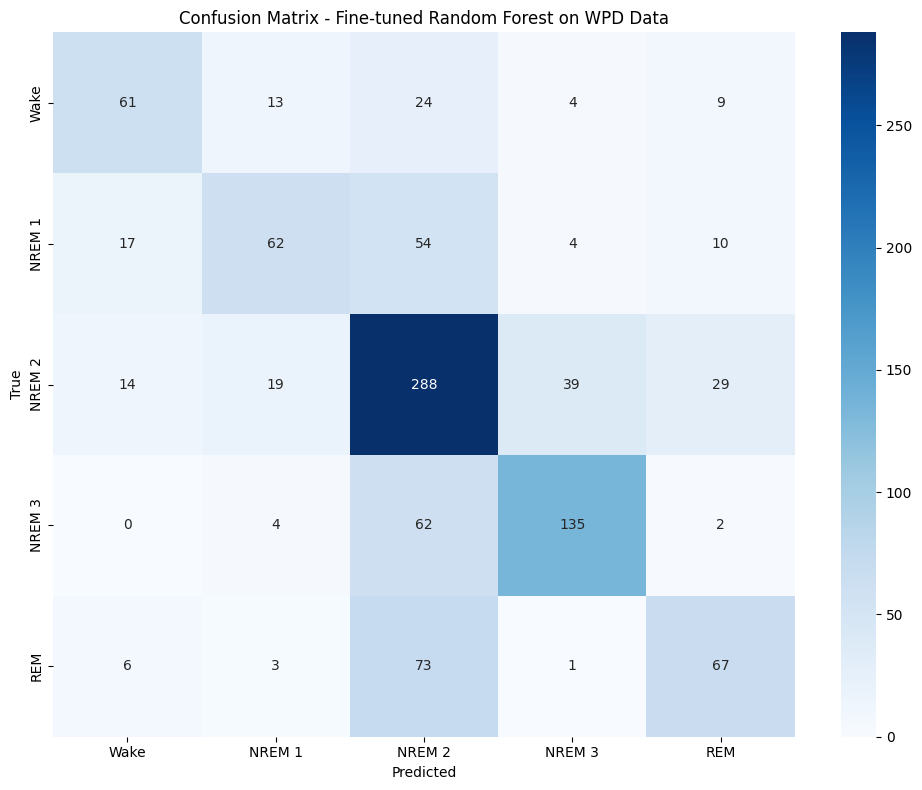

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

import matplotlib.pyplot as plt

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define the parameter grid for fine-tuning
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced']
}

# Perform grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the WPD data
grid_search.fit(X_train_wpd, y_train_wpd)

# Display the best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_wpd)
accuracy = accuracy_score(y_test_wpd, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_wpd, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_wpd, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fine-tuned Random Forest on WPD Data')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import time
import matplotlib.pyplot as plt

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define the parameter grid for fine-tuning
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced']
}

# Start timing
start_time = time.time()

# Perform grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the spectrogram data
print("Starting grid search on spectrogram data...")
grid_search.fit(X_train_sxx, y_train_sxx)
print(f"Grid search completed in {time.time() - start_time:.2f} seconds")

# Display the best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_sxx)
accuracy = accuracy_score(y_test_sxx, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_sxx, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_sxx, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fine-tuned Random Forest on Spectrogram Data')
plt.tight_layout()
plt.show()

# Feature importance
feature_importances = best_model.named_steps['rf'].feature_importances_
top_n = 20
indices = np.argsort(feature_importances)[-top_n:]
plt.figure(figsize=(12, 6))
plt.barh(range(top_n), feature_importances[indices])
plt.yticks(range(top_n), [f'Feature {i}' for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

Starting grid search on spectrogram data...
Fitting 3 folds for each of 216 candidates, totalling 648 fits


# Random Forest:

## Random Forest Results Summary

### 1. Basic Random Forest on Raw EEG Signals
- Applied to normalized time-series data
- Accuracy: 0.44
- Limited performance on raw temporal data without feature extraction

### 2. Random Forest with PCA
- Applied dimensionality reduction before classification
- Best parameters: PCA with 50 components
- Improved accuracy: 0.5010
- Reduced computational burden while maintaining relevant information

### 3. Random Forest with Wavelet Packet Decomposition (WPD) Features
- Applied statistical feature extraction from wavelet coefficients
- Accuracy: 0.63
- Significantly better at capturing multi-resolution time-frequency patterns

### 4. Random Forest with Spectrogram Features
- Used flattened spectrograms as input features
- Accuracy: 0.55
- Effective at learning from time-frequency representations

### 5. Fine-tuned Random Forest with WPD Features
- Best parameters: 200 trees, max_depth=30, min_samples_split=2, min_samples_leaf=1, class_weight='balanced'
- Accuracy: 0.61
- Improved class balance and deeper trees captured complex patterns

### 6. Fine-tuned Random Forest with Spectrogram Features
- Achieved highest performance among RF models
- Accuracy: 0.59
- PCA preprocessing helped focus on most relevant spectrogram components
- Good performance across all sleep stages, particularly for Stage 2 (NREM)

The confusion matrix revealed better distinction between Wake (0) and NREM stages, while some misclassification occurred between similar stages (NREM 1 and REM). Feature importance analysis indicated that certain frequency bands were particularly discriminative for sleep stage classification.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.layers import Conv2D, AveragePooling2D, SeparableConv2D
from tensorflow.keras.layers import BatchNormalization, Input, Flatten
from tensorflow.keras.constraints import max_norm

def EEGNet(nb_classes, Chans=1, Samples=178, dropoutRate=0.5):
    input_shape = (Chans, Samples, 1)
    input_layer = Input(shape=input_shape)

    # Block 1
    block1 = Conv2D(16, (1, 51), padding='same', input_shape=input_shape)(input_layer)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = Dropout(dropoutRate)(block1)
    block1 = AveragePooling2D((1, 4))(block1)

    # Block 2
    block2 = SeparableConv2D(32, (1, 15), padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = Dropout(dropoutRate)(block2)
    block2 = AveragePooling2D((1, 8))(block2)

    # Classification
    flatten = Flatten()(block2)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.25))(flatten)
    softmax = Activation('softmax')(dense)

    return Model(inputs=input_layer, outputs=softmax)

# Reshape data for EEGNet - assuming single channel data
X_eegnet = X_train_norm.reshape(X_train_norm.shape[0], 1, X_train_norm.shape[1], 1)

# Convert labels to categorical if needed
from tensorflow.keras.utils import to_categorical
y_categorical = to_categorical(y_train)

# Compile and train
model = EEGNet(nb_classes=len(np.unique(y_train)))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_eegnet, y_categorical, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4550 - loss: 1.4238 - val_accuracy: 0.0000e+00 - val_loss: 1.8566
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5406 - loss: 1.1302 - val_accuracy: 0.2310 - val_loss: 2.3645
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5878 - loss: 0.9813 - val_accuracy: 0.2330 - val_loss: 2.7441
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5954 - loss: 0.9393 - val_accuracy: 0.2120 - val_loss: 2.8994
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6064 - loss: 0.9090 - val_accuracy: 0.2020 - val_loss: 3.1079
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6076 - loss: 0.9025 - val_accuracy: 0.2010 - val_loss: 3.1887
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6123 - loss: 0.8848 - val_accuracy: 0.1900 - val_loss: 3.2890
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6159 - loss: 0.8725 - val_

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 0.6027

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.77      0.65       511
           1       0.39      0.34      0.36       697
           2       0.59      0.78      0.67      2000
           3       0.79      0.80      0.79      1040
           4       0.00      0.00      0.00       751

    accuracy                           0.60      4999
   macro avg       0.47      0.54      0.49      4999
weighted avg       0.51      0.60      0.55      4999



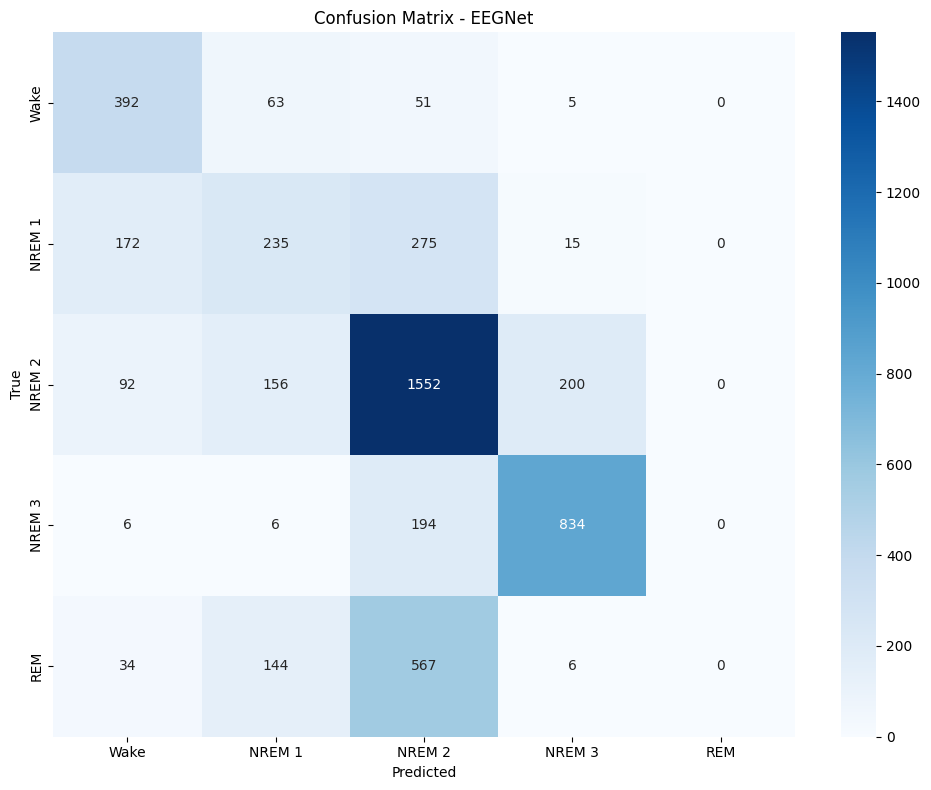

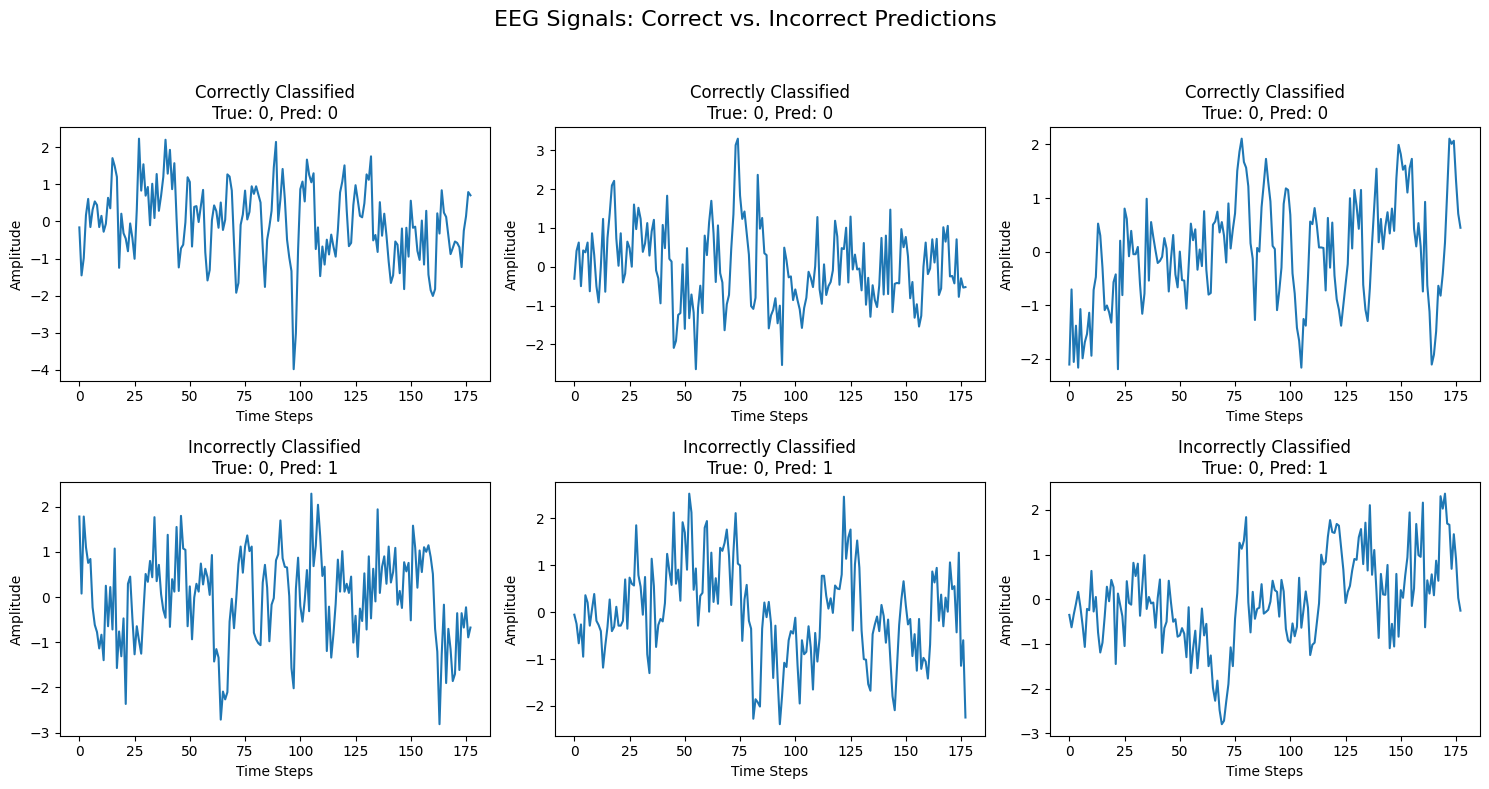

In [ ]:
# Evaluate the model
y_pred_classes = np.argmax(model.predict(X_eegnet), axis=1)
y_true = np.argmax(y_categorical, axis=1)

# Calculate accuracy
acc = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {acc:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - EEGNet')
plt.tight_layout()
plt.show()

# Plot a sample of correctly and incorrectly classified epochs
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('EEG Signals: Correct vs. Incorrect Predictions', fontsize=16)

correct = np.where(y_pred_classes == y_true)[0]
incorrect = np.where(y_pred_classes != y_true)[0]

for i, (title, indices) in enumerate([("Correctly Classified", correct),
                                     ("Incorrectly Classified", incorrect)]):
    for j in range(3):
        if len(indices) > j:
            idx = indices[j]
            axes[i, j].plot(X_train_norm[idx])
            axes[i, j].set_title(f"{title}\nTrue: {y_true[idx]}, Pred: {y_pred_classes[idx]}")
            axes[i, j].set_xlabel("Time Steps")
            axes[i, j].set_ylabel("Amplitude")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split the data into training and testing sets
X_train_eegnet, X_test_eegnet, y_train_eegnet, y_test_eegnet = train_test_split(
    X_eegnet, y_categorical, test_size=0.2, random_state=42
)

# Train the EEGNet model
model = EEGNet(nb_classes=y_categorical.shape[1])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_eegnet, y_train_eegnet, batch_size=32, epochs=30, validation_split=0.2)

# Test the model
y_pred_eegnet = model.predict(X_test_eegnet)
y_pred_classes = y_pred_eegnet.argmax(axis=1)
y_true_classes = y_test_eegnet.argmax(axis=1)

# Print the results
print("Accuracy:", accuracy_score(y_true_classes, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_true_classes, y_pred_classes))


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.3502 - loss: 1.5383 - val_accuracy: 0.4288 - val_loss: 1.5012
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4419 - loss: 1.3331 - val_accuracy: 0.2600 - val_loss: 1.4392
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4810 - loss: 1.2291 - val_accuracy: 0.3413 - val_loss: 1.3789
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5111 - loss: 1.1563 - val_accuracy: 0.5088 - val_loss: 1.1455
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5230 - loss: 1.1196 - val_accuracy: 0.5688 - val_loss: 1.0408
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5381 - loss: 1.1026 - val_accuracy: 0.5900 - val_loss: 1.0079
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5411 - loss: 1.0943 - val_accuracy: 0.6050 - val_loss: 0.9841
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5563 - loss: 1.0686 - val_accu

Augmenting training data...
Original training set size: 3999, Augmented training set size: 11997
Creating and training improved EEGNet model...
Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4108 - loss: 1.4337 - val_accuracy: 0.5092 - val_loss: 1.3291
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5365 - loss: 1.1271 - val_accuracy: 0.5771 - val_loss: 1.0473
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5520 - loss: 1.0840 - val_accuracy: 0.6075 - val_loss: 0.9869
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5726 - loss: 1.0377 - val_accuracy: 0.6071 - val_loss: 0.9802
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.5779 - loss: 1.0167 - val_accuracy: 0.6158 - val_loss: 0.9656
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5898 - loss: 1.0024 - val_accuracy: 0.6192 - val_loss: 0.9527
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5964 - loss

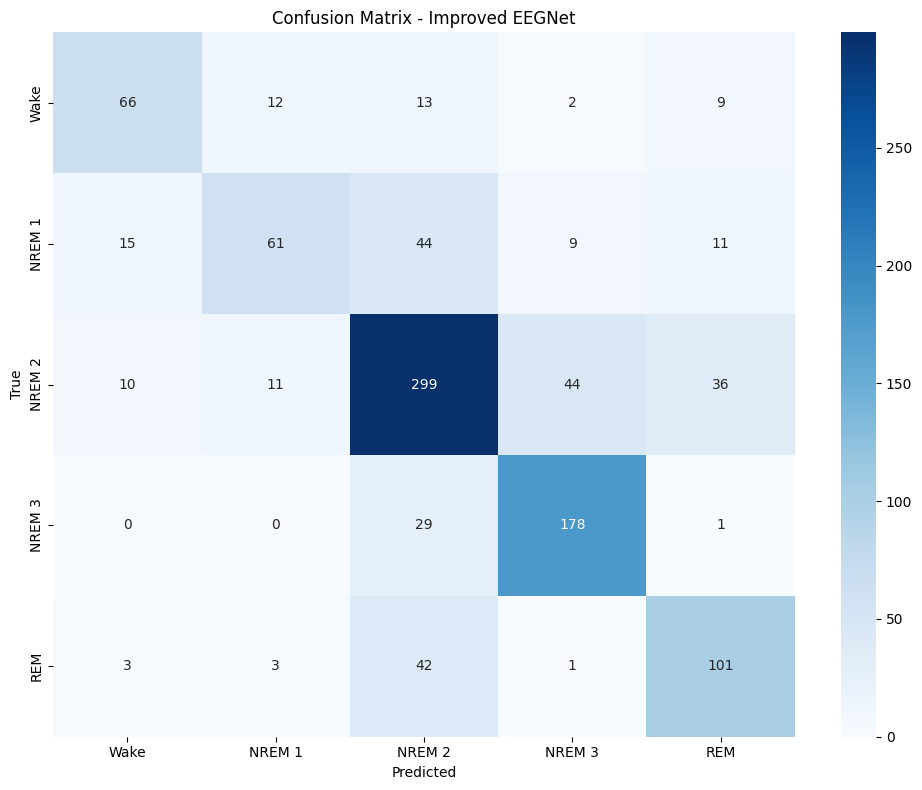

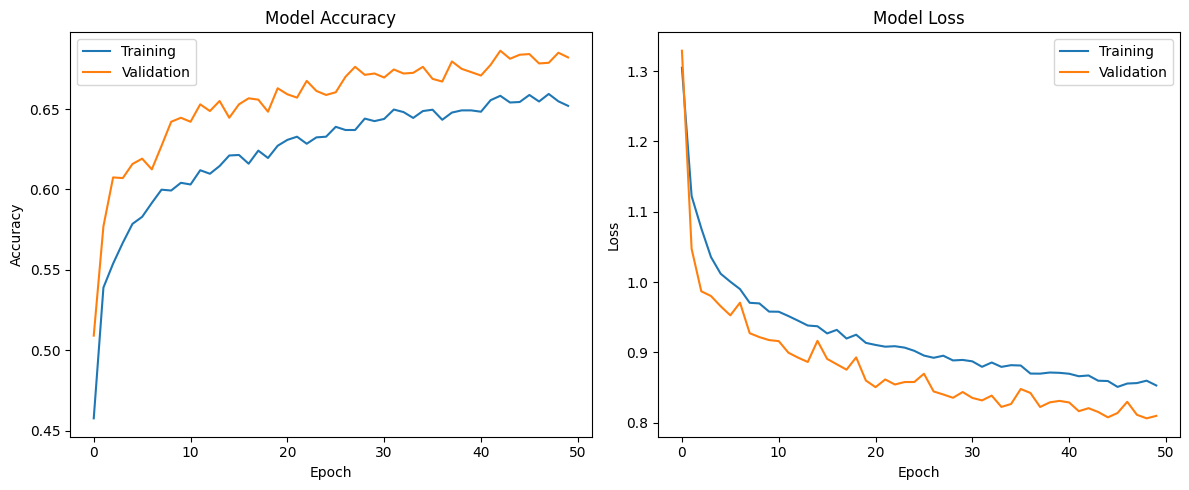

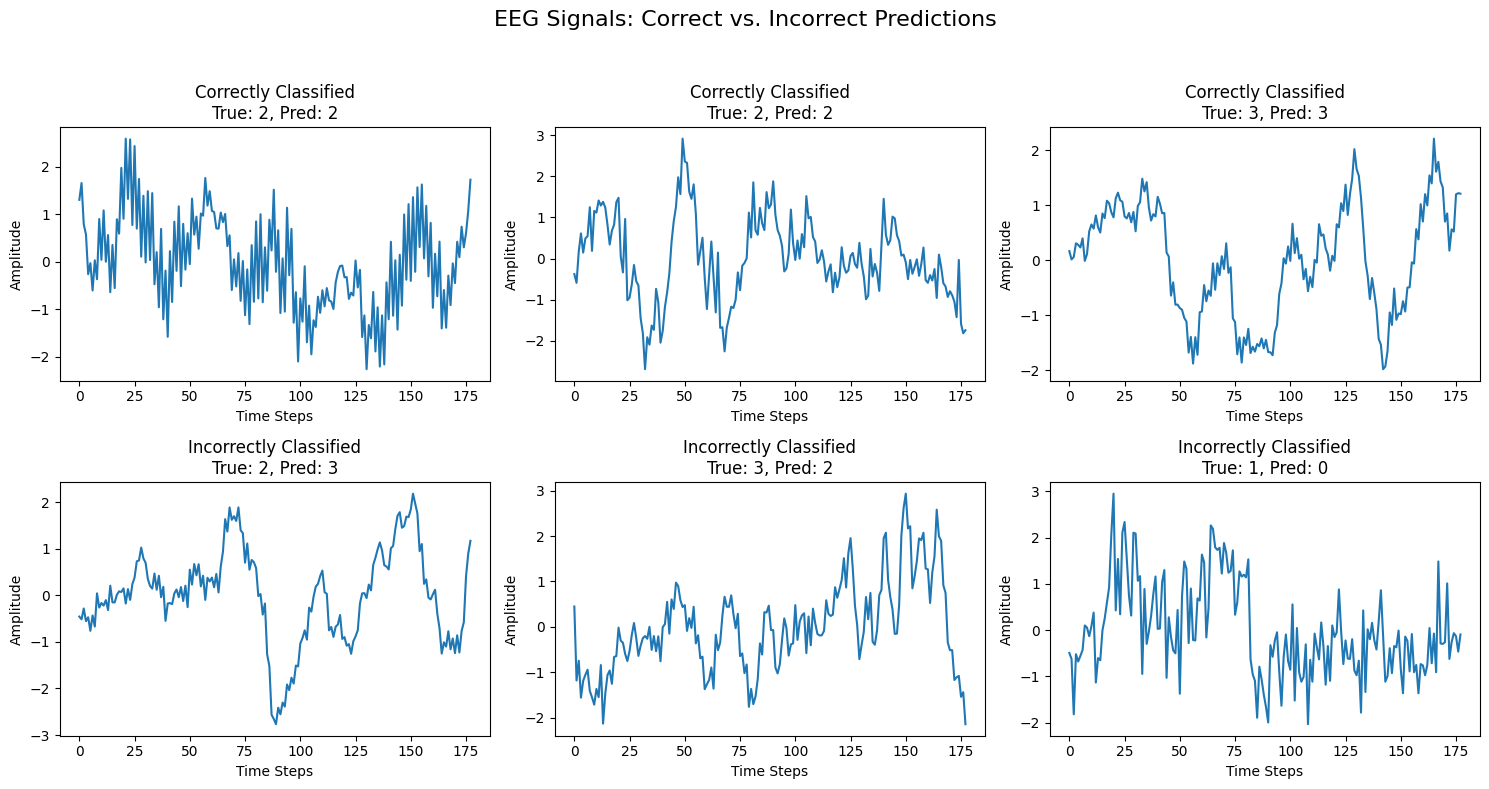

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.layers import Conv2D, AveragePooling2D, SeparableConv2D
from tensorflow.keras.layers import BatchNormalization, Input, Flatten
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time

def EEGNet_improved(nb_classes, Chans=1, Samples=178, dropoutRate=0.5):
    input_shape = (Chans, Samples, 1)
    input_layer = Input(shape=input_shape)

    # Block 1: Temporal Convolution - capture frequency filters
    block1 = Conv2D(32, (1, 64), padding='same', use_bias=False)(input_layer)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = Dropout(dropoutRate)(block1)
    block1 = AveragePooling2D((1, 4))(block1)

    # Block 2: Separable Convolution - capture spatial dependencies
    block2 = SeparableConv2D(64, (1, 32), padding='same', use_bias=False)(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = Dropout(dropoutRate)(block2)
    block2 = AveragePooling2D((1, 8))(block2)

    # Block 3: Additional depth
    block3 = SeparableConv2D(128, (1, 16), padding='same', use_bias=False)(block2)
    block3 = BatchNormalization()(block3)
    block3 = Activation('elu')(block3)
    block3 = Dropout(dropoutRate)(block3)
    block3 = AveragePooling2D((1, 2))(block3)

    # Classification
    flatten = Flatten()(block3)
    dense1 = Dense(128, kernel_constraint=max_norm(0.25))(flatten)
    dense1 = Activation('elu')(dense1)
    dense1 = Dropout(dropoutRate)(dense1)
    dense2 = Dense(nb_classes, kernel_constraint=max_norm(0.25))(dense1)
    softmax = Activation('softmax')(dense2)

    return Model(inputs=input_layer, outputs=softmax)

def augment_eeg(X_train, y_train, augmentation_factor=2):
    X_augmented = [X_train]
    y_augmented = [y_train]

    for i in range(augmentation_factor - 1):
        # Time warping - stretch/compress signal slightly
        X_aug = np.copy(X_train)
        for j in range(len(X_aug)):
            # Random noise addition (SNR between 10-20dB)
            noise_level = np.random.uniform(0.1, 0.3) * np.std(X_aug[j])
            X_aug[j] = X_aug[j] + np.random.normal(0, noise_level, size=X_aug[j].shape)

            # Random time shift (±5%) - with safety check
            max_shift = max(1, int(X_aug[j].shape[1]*0.05))  # Ensure at least 1
            shift = np.random.randint(-max_shift, max_shift + 1)  # +1 because upper bound is exclusive

            if shift > 0:
                # Shape is likely (1, 178, 1) so we shift along axis 1
                X_aug[j, :, :-shift, :] = X_aug[j, :, shift:, :]
                X_aug[j, :, -shift:, :] = 0  # Zero-pad the end
            elif shift < 0:
                abs_shift = abs(shift)
                X_aug[j, :, abs_shift:, :] = X_aug[j, :, :-abs_shift, :]
                X_aug[j, :, :abs_shift, :] = 0  # Zero-pad the beginning

        X_augmented.append(X_aug)
        y_augmented.append(y_train)

    return np.vstack(X_augmented), np.concatenate(y_augmented)

# Start timing
start_time = time.time()

# Reshape data for EEGNet - assuming single channel data
X_eegnet = X_train_norm.reshape(X_train_norm.shape[0], 1, X_train_norm.shape[1], 1)

# Convert labels to categorical
y_categorical = to_categorical(y_train)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X_eegnet, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical.argmax(axis=1)
)

# Apply augmentation to training data only
print("Augmenting training data...")
X_train_aug, y_train_aug = augment_eeg(X_train, y_train_cat, augmentation_factor=3)
print(f"Original training set size: {len(X_train)}, Augmented training set size: {len(X_train_aug)}")

# Define callbacks for better training
callbacks = [
    EarlyStopping(monitor='accuracy', patience=10, verbose=1, restore_best_weights=True),
]

# Create the improved model
print("Creating and training improved EEGNet model...")
model = EEGNet_improved(nb_classes=5, Samples=X_train.shape[2])
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Train with the augmented data
history = model.fit(
    X_train_aug, y_train_aug,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on the test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training completed in {time.time() - start_time:.2f} seconds")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Improved EEGNet')
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Visualize sample predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('EEG Signals: Correct vs. Incorrect Predictions', fontsize=16)

correct = np.where(y_pred == y_true)[0]
incorrect = np.where(y_pred != y_true)[0]

for i, (title, indices) in enumerate([("Correctly Classified", correct),
                                     ("Incorrectly Classified", incorrect)]):
    for j in range(3):
        if len(indices) > j:
            idx = indices[j]
            # Reshape back to 1D for plotting
            signal = X_test[idx].reshape(-1)
            axes[i, j].plot(signal)
            axes[i, j].set_title(f"{title}\nTrue: {y_true[idx]}, Pred: {y_pred[idx]}")
            axes[i, j].set_xlabel("Time Steps")
            axes[i, j].set_ylabel("Amplitude")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Result And Discussion:

The EEGNet gave a really good result it may give a better one combined with other models

# EEGNet:

Data to use: Raw normalized data (X_train_norm) reshaped into 2D format (channels × time points)
Suitability:

- Perfect for this dataset size
- Designed specifically for EEG
- Will learn spatial filters automatically

# RNN:

Original shape: (4999, 17, 19, 1)
LSTM input shape: (4999, 17, 19)
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3533 - loss: 2.1738

125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.3536 - loss: 2.1724 - val_accuracy: 0.4020 - val_loss: 1.7271
Epoch 2/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4011 - loss: 1.6745

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4011 - loss: 1.6735 - val_accuracy: 0.4060 - val_loss: 1.4683
Epoch 3/50
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4128 - loss: 1.4656

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4130 - loss: 1.4652 - val_accuracy: 0.4810 - val_loss: 1.3018
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4613 - loss: 1.3737 - val_accuracy: 0.4750 - val_loss: 1.2767
Epoch 5/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4637 - loss: 1.3327

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4638 - loss: 1.3326 - val_accuracy: 0.5180 - val_loss: 1.2184
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4784 - loss: 1.2970

...

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5223 - loss: 1.2123 - val_accuracy: 0.5480 - val_loss: 1.1409
Epoch 14/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5194 - loss: 1.2092 - val_accuracy: 0.5340 - val_loss: 1.1307
Epoch 15/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5314 - loss: 1.1855 - val_accuracy: 0.5390 - val_loss: 1.1318
Epoch 16/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5292 - loss: 1.2033 - val_accuracy: 0.5380 - val_loss: 1.1304
Epoch 17/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5264 - loss: 1.1910 - val_accuracy: 0.5330 - val_loss: 1.1476
Epoch 18/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5216 - loss: 1.1962 - val_accuracy: 0.5450 - val_loss: 1.1184
Epoch 19/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5347 - loss: 1.1836 - val_accuracy: 0.5380 - val_loss: 1.1189
Epoch 20/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5379 - loss: 1.1637

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5378 - loss: 1.1637 - val_accuracy: 0.5540 - val_loss: 1.1173
Epoch 21/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5433 - loss: 1.1677 - val_accuracy: 0.5380 - val_loss: 1.1132
Epoch 22/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5448 - loss: 1.1606 - val_accuracy: 0.5520 - val_loss: 1.1098
Epoch 23/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5592 - loss: 1.1598

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5588 - loss: 1.1598 - val_accuracy: 0.5600 - val_loss: 1.1049
Epoch 24/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5539 - loss: 1.1487 - val_accuracy: 0.5550 - val_loss: 1.1037
Epoch 25/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5283 - loss: 1.1600 - val_accuracy: 0.5370 - val_loss: 1.1359
Epoch 26/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5314 - loss: 1.1643 - val_accuracy: 0.5520 - val_loss: 1.1176
Epoch 27/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5499 - loss: 1.1469 - val_accuracy: 0.5550 - val_loss: 1.1174
Epoch 28/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5467 - loss: 1.1550 - val_accuracy: 0.5550 - val_loss: 1.0982
Epoch 29/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5530 - loss: 1.1453 - val_accuracy: 0.5510 - val_loss: 1.1053
Epoch 30/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.5572 - loss: 1.1273 - val_accuracy

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5669 - loss: 1.1193 - val_accuracy: 0.5690 - val_loss: 1.0899
Epoch 34/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5580 - loss: 1.1225 - val_accuracy: 0.5560 - val_loss: 1.0985
Epoch 35/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5512 - loss: 1.1306 - val_accuracy: 0.5590 - val_loss: 1.0926
Epoch 36/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5562 - loss: 1.1173 - val_accuracy: 0.5630 - val_loss: 1.1000
Epoch 37/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5692 - loss: 1.1156 - val_accuracy: 0.5660 - val_loss: 1.1023
Epoch 38/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5750 - loss: 1.1042 - val_accuracy: 0.5580 - val_loss: 1.1122
Epoch 39/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5607 - loss: 1.1303 - val_accuracy: 0.5640 - val_loss: 1.0965
Epoch 40/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5625 - loss: 1.1120 - val_accuracy

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5736 - loss: 1.1087 - val_accuracy: 0.5770 - val_loss: 1.0944
Epoch 42/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5629 - loss: 1.1099 - val_accuracy: 0.5690 - val_loss: 1.0978
Epoch 43/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5779 - loss: 1.1122 - val_accuracy: 0.5600 - val_loss: 1.0907
Epoch 44/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5852 - loss: 1.0949 - val_accuracy: 0.5440 - val_loss: 1.1213
Epoch 45/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5798 - loss: 1.0982 - val_accuracy: 0.5690 - val_loss: 1.0945
Epoch 46/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5951 - loss: 1.0869 - val_accuracy: 0.5680 - val_loss: 1.1011
Epoch 47/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5745 - loss: 1.0896 - val_accuracy: 0.5600 - val_loss: 1.1041
Epoch 48/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5831 - loss: 1.1054 - val_accuracy

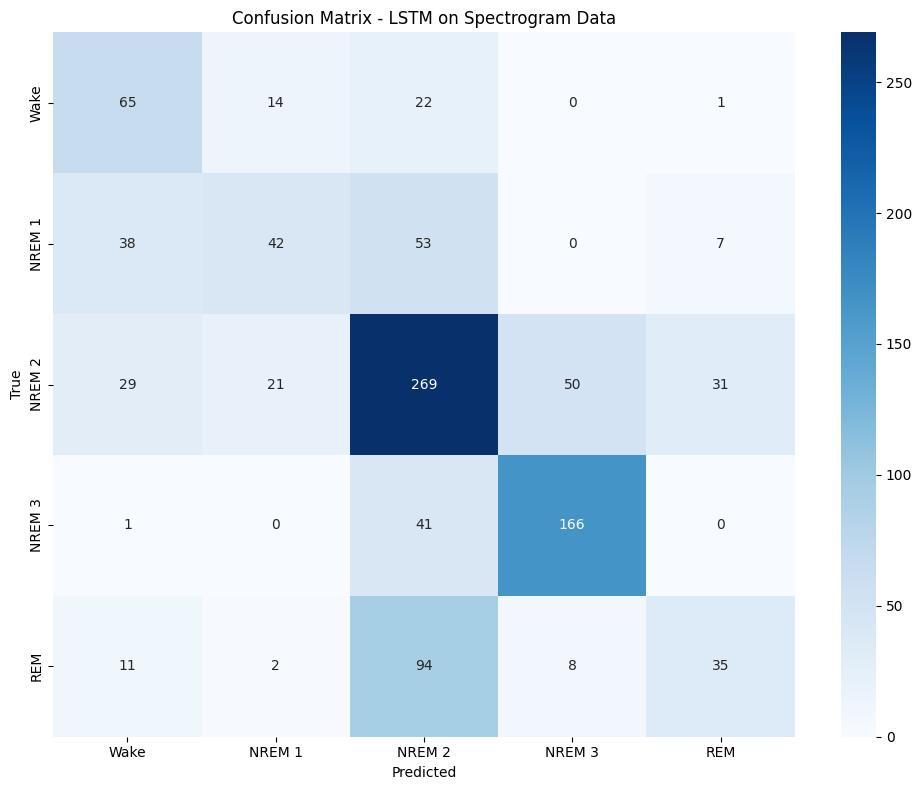

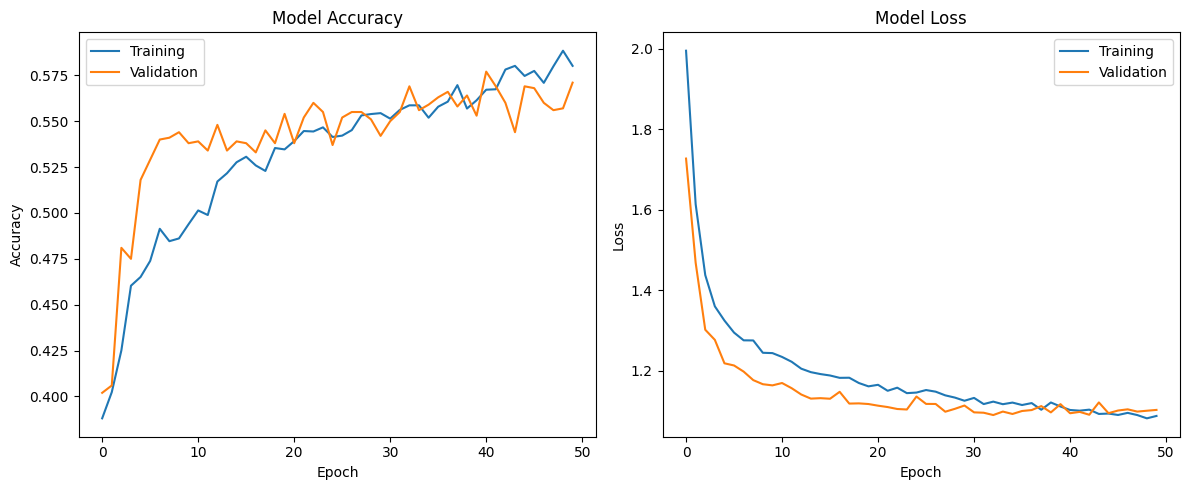

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Data augmentation function for EEG spectrograms
def augment_data(X, noise_factor=0.05, max_shift=5):
    X_aug = X.copy()
    # Add Gaussian noise
    noise = np.random.normal(0, noise_factor, X.shape)
    X_aug += noise
    # Random time shift
    for i in range(X.shape[0]):
        shift = np.random.randint(-max_shift, max_shift)
        X_aug[i] = np.roll(X_aug[i], shift, axis=1)
    return X_aug

# Reshape spectrogram data to fit LSTM input shape (batch_size, time_steps, features)
print("Original shape:", Sxx_norm_log.shape)

# Reshape based on actual dimensions
if len(Sxx_norm_log.shape) == 4:  # If shape is (samples, freq_bins, time_bins, channels)
    X_lstm = Sxx_norm_log.squeeze(axis=-1)  # Remove channel dimension if it exists
else:
    # Already in 3D format (samples, freq_bins, time_bins)
    X_lstm = Sxx_norm_log

print("LSTM input shape:", X_lstm.shape)

# Convert targets to categorical
y_categorical = to_categorical(y_train)

# Split the data
X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_lstm, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical.argmax(axis=1)
)

# Apply data augmentation to training data
X_train_lstm_aug = augment_data(X_train_lstm, noise_factor=0.05, max_shift=5)

# Build the LSTM model with L2 regularization and adjusted architecture
model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
         kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    LSTM(16, kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(len(np.unique(y_train)), activation='softmax', kernel_regularizer=l2(0.01))
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks for training
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_lstm_model.h5', monitor='val_accuracy', save_best_only=True)
]

# Train the model with augmented data
history = model.fit(
    X_train_lstm_aug, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=callbacks,
    verbose=1
)

# Evaluate the model
y_pred_proba = model.predict(X_val_lstm)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_val_lstm, axis=1)

# Display performance metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LSTM on Spectrogram Data')
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# MLP

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2794 - loss: 2.0523 - val_accuracy: 0.4462 - val_loss: 1.5380 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4524 - loss: 1.4770 - val_accuracy: 0.5312 - val_loss: 1.2661 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4613 - loss: 1.3747 - val_accuracy: 0.5213 - val_loss: 1.2973 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5005 - loss: 1.3105 - val_accuracy: 0.5362 - val_loss: 1.2150 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5079 - loss: 1.2871 - val_accuracy: 0.5375 - val_loss: 1.1714 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5331 - loss: 1.1753 - val_accuracy: 0.5250 - val_loss: 1.1636 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5243 - loss: 1.1765 - val_accuracy:

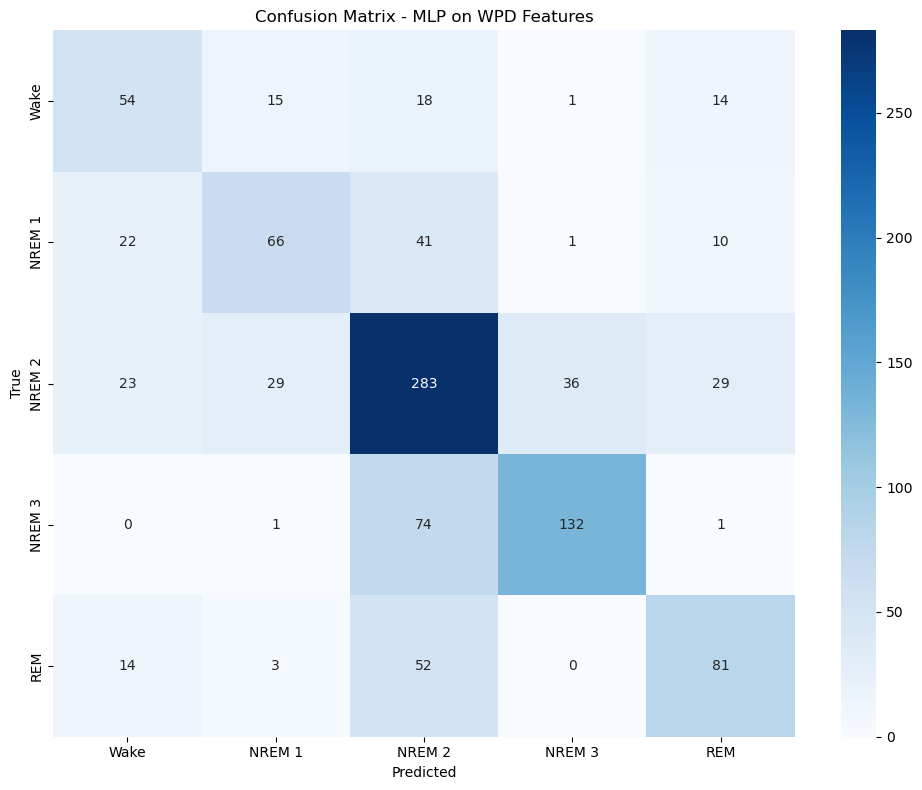

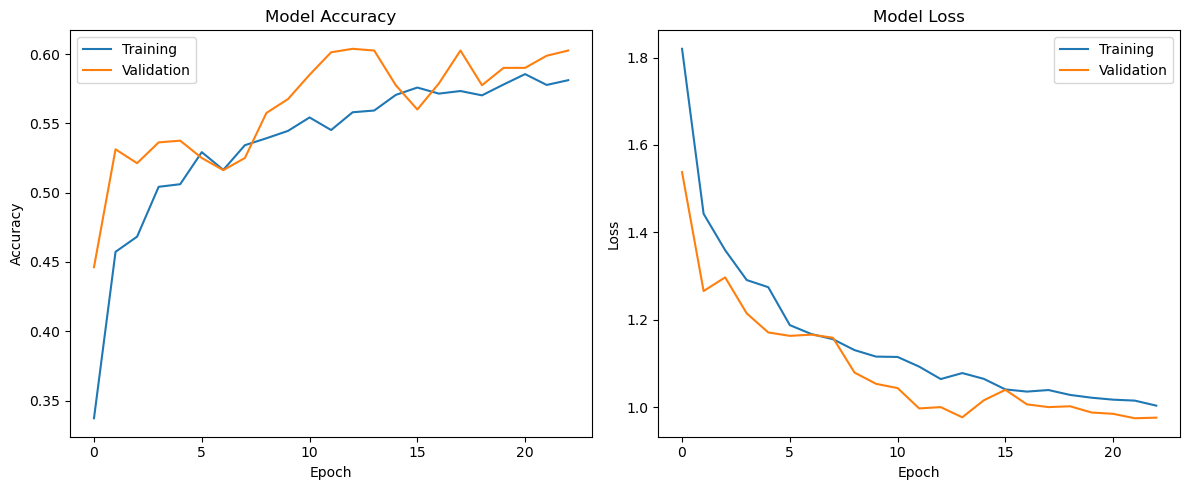

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data - using the wavelet packet decomposition features
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_wpd_features, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convert labels to categorical
y_train_cat = to_categorical(y_train_mlp)
y_test_cat = to_categorical(y_test_mlp)

# Define model architecture
model = Sequential()

# Input layer
model.add(Dense(256, activation='relu', input_shape=(X_train_mlp.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer
model.add(Dense(5, activation='softmax'))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-6, monitor='val_loss')
]

# Train model
history = model.fit(
    X_train_mlp, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluate model
y_pred_proba = model.predict(X_test_mlp)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test_mlp

# Print accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"MLP Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MLP on WPD Features')
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Data:

Data imported to test the final models and avoid any errors.

In [ ]:
train_df = pd.read_csv('Sleep Train 5000.csv', header=None)

train_df.rename(columns={0: 'class'}, inplace=True)
train_df.head()

y = train_df.iloc[:, 0].astype(int)

X = train_df.iloc[:, 1:].values

print(f"X_train shape: {X.shape}   (epochs × time-steps)")
print(f"y_train shape: {y.shape}   (labels)")

X_train shape: (4999, 178)   (epochs × time-steps)
y_train shape: (4999,)   (labels)


In [ ]:
def z_score_per_epoch(X):
    means = X.mean(axis=1, keepdims=True)
    stds = X.std(axis=1, keepdims=True)
    stds[stds == 0] = 1
    return (X - means) / stds

X_norm = z_score_per_epoch(X)

print(X_norm.shape)

In [ ]:
# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)

# Print the data shapes to confirm splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check class distribution in each split
print("\nClass distribution:")
print("Training set:", np.bincount(y_train))
print("Test set:", np.bincount(y_test))

X_train shape: (3999, 178)
X_test shape: (1000, 178)
y_train shape: (3999,)
y_test shape: (1000,)

Class distribution:
Training set: [ 409  557 1600  832  601]
Test set: [102 140 400 208 150]


# Utility Function:

In [ ]:
def mixup(X, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(X))
    X_mix = lam * X + (1 - lam) * X[idx]
    y_mix = lam * y + (1 - lam) * y[idx]
    return X_mix, y_mix.astype(int)  # or soft-labels


In [ ]:
def time_shift(X, max_shift=10):
    shifted = []
    for epoch in X:
        shift = np.random.randint(-max_shift, max_shift)
        shifted_epoch = np.roll(epoch, shift)
        shifted.append(shifted_epoch)
    return np.array(shifted)


In [ ]:
def add_gaussian_noise(X, noise_level=0.01):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise


# Augmented Data:

In [ ]:
# 1. Original
X_all = X_train.copy()
y_all = y_train.copy()

# 2. Augment
X_noise = add_gaussian_noise(X_train)
X_shift = time_shift(X_train)
X_mix, y_mix = mixup(X_train, y_train.values)

# 3. Stack all
X_aug = np.vstack([X_all, X_noise, X_shift, X_mix])
y_aug = np.concatenate([y_all, y_all, y_all, y_mix])


In [ ]:
print(X_aug.shape)
print(y_aug.shape)

(15996, 178)
(15996,)


# XGboost Model:

In [ ]:
tuned_xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    max_depth=7,
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.6,
    min_child_weight= 5,
    gamma=0,
    random_state=42
)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# Apply PCA (retain 95% of variance)
pca = PCA(n_components=0.95)
X_pca_best = pca.fit_transform(X_aug)

# Train XGBoost on reduced data

scores = cross_val_score(tuned_xgb_clf, X_pca_best, y_aug, cv=5)

print(f"Cross-validated tuned model augmented accuracy with PCA: {scores.mean():.2f}")


Cross-validated tuned model augmented accuracy with PCA: 0.75


In [ ]:


X_train_PCA, X_test_PCA, y_train_PCA, y_test_PCA = train_test_split(
    X_pca_best, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

# Fit the model on the augmented PCA data
tuned_xgb_clf.fit(X_train_PCA, y_train_PCA)

# Predictions on validation and test set
test_predictions = tuned_xgb_clf.predict(X_test_PCA)

# Evaluate the model on test set
print("\nTest Results:")
test_accuracy = accuracy_score(y_test_PCA, test_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test_PCA, test_predictions,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))
print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test_PCA, test_predictions))


Test Results:
Test Accuracy: 0.7262

Test Classification Report:
              precision    recall  f1-score   support

        Wake       0.93      0.82      0.87       339
      NREM 1       0.82      0.63      0.71       509
      NREM 2       0.71      0.86      0.78      1313
      NREM 3       0.65      0.62      0.63       661
         REM       0.63      0.50      0.56       378

    accuracy                           0.73      3200
   macro avg       0.75      0.69      0.71      3200
weighted avg       0.73      0.73      0.72      3200


Test Confusion Matrix:
[[ 279   24   33    0    3]
 [  16  321  168    1    3]
 [   4   35 1127  145    2]
 [   0    0  148  408  105]
 [   1   10  104   74  189]]


In [ ]:
X_pca_best.shape

(15996, 83)

### Gradient boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

In [ ]:
'''cv_scores = cross_val_score(gb_clf, X_train_PCA, y_train_PCA, cv=5, scoring='accuracy')
print(f"Cross-validated training accuracy: {cv_scores.mean():.4f}")'''

'cv_scores = cross_val_score(gb_clf, X_train_PCA, y_train_PCA, cv=5, scoring=\'accuracy\')\nprint(f"Cross-validated training accuracy: {cv_scores.mean():.4f}")'

In [ ]:
gb_clf.fit(X_train_PCA, y_train_PCA)

y_pred_gb = gb_clf.predict(X_test_PCA)

print("\nTest Accuracy:", accuracy_score(y_test_PCA, y_pred_gb))
print("\nClassification Report:")
print(classification_report(y_test_PCA, y_pred_gb, target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_PCA, y_pred_gb))


Test Accuracy: 0.706875

Classification Report:
              precision    recall  f1-score   support

        Wake       0.91      0.77      0.84       339
      NREM 1       0.78      0.58      0.66       509
      NREM 2       0.68      0.85      0.75      1313
      NREM 3       0.67      0.61      0.64       661
         REM       0.65      0.50      0.56       378

    accuracy                           0.71      3200
   macro avg       0.74      0.66      0.69      3200
weighted avg       0.71      0.71      0.70      3200


Confusion Matrix:
[[ 261   30   43    2    3]
 [  15  294  188    4    8]
 [   6   36 1113  154    4]
 [   0    2  166  406   87]
 [   4   14  132   40  188]]


# EEGNet:

Using existing train/test split data...
Augmenting training data...
Original training set size: 3999, Augmented training set size: 11997
Creating and training improved EEGNet model...
Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.4172 - loss: 1.4212 - val_accuracy: 0.4762 - val_loss: 1.3251
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5317 - loss: 1.1284 - val_accuracy: 0.5992 - val_loss: 1.0205
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.5669 - loss: 1.0725 - val_accuracy: 0.5975 - val_loss: 0.9859
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5821 - loss: 1.0378 - val_accuracy: 0.6204 - val_loss: 0.9444
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5908 - loss: 1.0042 - val_accuracy: 0.6150 - val_loss: 0.9383
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5954 - loss: 0.9880 - val_accuracy: 0.6121 - val_loss: 0.9424
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━

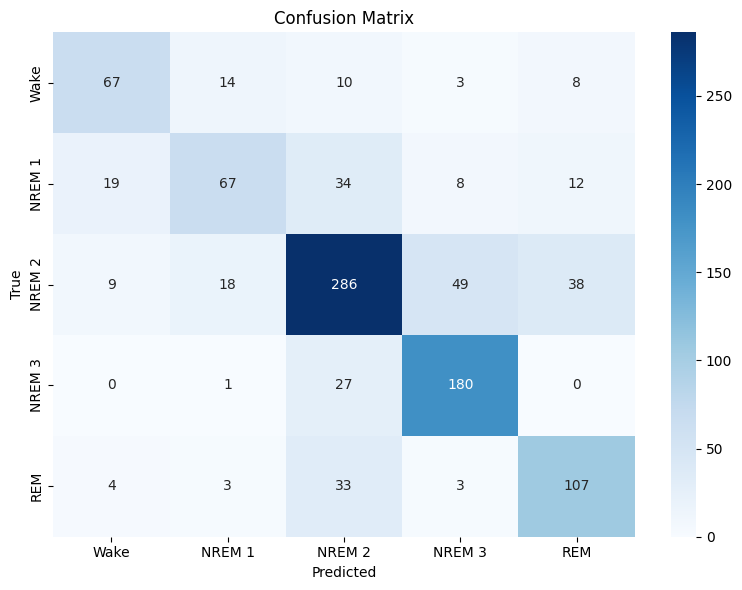

In [ ]:
def EEGNet_improved(nb_classes, Chans=1, Samples=178, dropoutRate=0.5):
    input_shape = (Chans, Samples, 1)
    input_layer = Input(shape=input_shape)

    # Block 1: Temporal Convolution - capture frequency filters
    block1 = Conv2D(32, (1, 64), padding='same', use_bias=False)(input_layer)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = Dropout(dropoutRate)(block1)
    block1 = AveragePooling2D((1, 4))(block1)

    # Block 2: Separable Convolution - capture spatial dependencies
    block2 = SeparableConv2D(64, (1, 32), padding='same', use_bias=False)(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = Dropout(dropoutRate)(block2)
    block2 = AveragePooling2D((1, 8))(block2)

    # Block 3: Additional depth
    block3 = SeparableConv2D(128, (1, 16), padding='same', use_bias=False)(block2)
    block3 = BatchNormalization()(block3)
    block3 = Activation('elu')(block3)
    block3 = Dropout(dropoutRate)(block3)
    block3 = AveragePooling2D((1, 2))(block3)

    # Classification
    flatten = Flatten()(block3)
    dense1 = Dense(128, kernel_constraint=max_norm(0.25))(flatten)
    dense1 = Activation('elu')(dense1)
    dense1 = Dropout(dropoutRate)(dense1)
    dense2 = Dense(nb_classes, kernel_constraint=max_norm(0.25))(dense1)
    softmax = Activation('softmax')(dense2)

    return Model(inputs=input_layer, outputs=softmax)

def augment_eeg(X_train, y_train, augmentation_factor=2):
    X_augmented = [X_train]
    y_augmented = [y_train]

    for i in range(augmentation_factor - 1):
        # Time warping - stretch/compress signal slightly
        X_aug = np.copy(X_train)
        for j in range(len(X_aug)):
            # Random noise addition (SNR between 10-20dB)
            noise_level = np.random.uniform(0.1, 0.3) * np.std(X_aug[j])
            X_aug[j] = X_aug[j] + np.random.normal(0, noise_level, size=X_aug[j].shape)

            # Random time shift (±5%) - with safety check
            max_shift = max(1, int(X_aug[j].shape[1]*0.05))  # Ensure at least 1
            shift = np.random.randint(-max_shift, max_shift + 1)  # +1 because upper bound is exclusive

            if shift > 0:
                # Shape is likely (1, 178, 1) so we shift along axis 1
                X_aug[j, :, :-shift, :] = X_aug[j, :, shift:, :]
                X_aug[j, :, -shift:, :] = 0  # Zero-pad the end
            elif shift < 0:
                abs_shift = abs(shift)
                X_aug[j, :, abs_shift:, :] = X_aug[j, :, :-abs_shift, :]
                X_aug[j, :, :abs_shift, :] = 0  # Zero-pad the beginning

        X_augmented.append(X_aug)
        y_augmented.append(y_train)

    return np.vstack(X_augmented), np.concatenate(y_augmented)

# Start timing
start_time = time.time()

# Use the existing train/test split that was already created
print("Using existing train/test split data...")

# Reshape data for EEGNet
X_train_eeg = X_train.reshape(X_train.shape[0], 1, X_train.shape[1], 1)
X_test_eeg = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], 1)

# Convert labels to categorical format
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Apply augmentation to training data only
print("Augmenting training data...")
X_train_aug, y_train_aug = augment_eeg(X_train_eeg, y_train_cat, augmentation_factor=3)
print(f"Original training set size: {len(X_train_eeg)}, Augmented training set size: {len(X_train_aug)}")

# Define callbacks for better training
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, verbose=1, restore_best_weights=True),
]

# Create and compile the model
print("Creating and training improved EEGNet model...")
model = EEGNet_improved(nb_classes=5, Samples=X_train_eeg.shape[2])
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Train with the augmented data
history = model.fit(
    X_train_aug, y_train_aug,
    batch_size=32,
    epochs=50,
    validation_split=0.2,  # Use 20% of the augmented training data for validation
    callbacks=callbacks,
    verbose=1
)

# Evaluate on the original test set (for true generalization assessment)
print("\nEvaluating on original test set...")
test_scores = model.evaluate(X_test_eeg, y_test_cat, verbose=0)
print(f"Test loss: {test_scores[0]:.4f}")
print(f"Test accuracy: {test_scores[1]:.4f}")

# Get predictions on test set
y_pred_proba = model.predict(X_test_eeg)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Training completed in {time.time() - start_time:.2f} seconds")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Stacking the models:

Getting predictions from base models for training data...
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Training meta-classifier...
Getting predictions from base models for test data...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Making final ensemble predictions...

Stacked Ensemble Test Results:
Test Accuracy: 0.6120

Test Classification Report:
              precision    recall  f1-score   support

        Wake       0.64      0.40      0.49       102
      NREM 1       0.51      0.25      0.34       140
      NREM 2       0.58      0.77      0.66       400
      NREM 3       0.73      0.79      0.76       208
         REM       0.58      0.42      0.49       150

    accuracy                           0.61      1000
   macro avg       0.61      0.53      0.55      1000
weighted avg       0.61      0.61      0.59      1000


Test Confusion Matrix:
[[ 41  18  34   3   6]
 [ 14  35  72   5  14]
 [  4  12 309  49  26]
 [  0   1  43 164   0]
 [  5   2  77   3  63]]


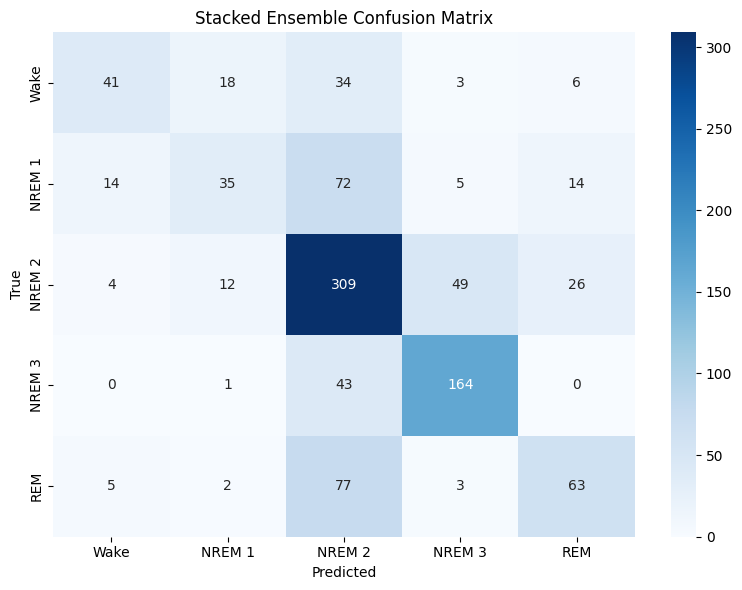


Model Comparison:
XGBoost Accuracy: 0.7262
EEGNet Accuracy: 0.7070
Stacked Ensemble Accuracy: 0.6120


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Create a function to get XGBoost predictions
def get_xgb_predictions(X_data):
    # Transform using PCA
    X_pca = pca.transform(X_data)
    # Get predictions
    return tuned_xgb_clf.predict_proba(X_pca)

# Create a function to get EEGNet predictions
def get_eegnet_predictions(X_data):
    # Reshape for EEGNet
    X_eeg = X_data.reshape(X_data.shape[0], 1, X_data.shape[1], 1)
    # Get predictions
    return model.predict(X_eeg)

# Get predictions from both models for training data
print("Getting predictions from base models for training data...")
xgb_train_pred = get_xgb_predictions(X_train)
eegnet_train_pred = get_eegnet_predictions(X_train)

# Combine predictions as features for meta-classifier
X_meta_train = np.hstack([xgb_train_pred, eegnet_train_pred])

# Create and train meta-classifier
print("Training meta-classifier...")
meta_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', C=1.0)
meta_clf.fit(X_meta_train, y_train)

# Get predictions from both models for test data
print("Getting predictions from base models for test data...")
xgb_test_pred = get_xgb_predictions(X_test)
eegnet_test_pred = get_eegnet_predictions(X_test)

# Combine predictions as features for meta-classifier
X_meta_test = np.hstack([xgb_test_pred, eegnet_test_pred])

# Make final predictions
print("Making final ensemble predictions...")
ensemble_predictions = meta_clf.predict(X_meta_test)

# Evaluate ensemble model
print("\nStacked Ensemble Test Results:")
test_accuracy = accuracy_score(y_test, ensemble_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, ensemble_predictions,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))
print("\nTest Confusion Matrix:")
cm = confusion_matrix(y_test, ensemble_predictions)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stacked Ensemble Confusion Matrix')
plt.tight_layout()
plt.show()

# Compare all models
print("\nModel Comparison:")
print(f"XGBoost Accuracy: {accuracy_score(y_test_PCA, test_predictions):.4f}")
print(f"EEGNet Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Stacked Ensemble Accuracy: {test_accuracy:.4f}")

Stacking the three models (XGboost + EEGnet + Gradient Boost)

Getting predictions from base models for training data...
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Training meta-classifier...
Getting predictions from base models for test data...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Making final ensemble predictions...

Stacked Ensemble Test Results:
Test Accuracy: 0.6090

Test Classification Report:
              precision    recall  f1-score   support

        Wake       0.59      0.39      0.47       102
      NREM 1       0.48      0.24      0.32       140
      NREM 2       0.59      0.76      0.66       400
      NREM 3       0.72      0.79      0.76       208
         REM       0.57      0.45      0.51       150

    accuracy                           0.61      1000
   macro avg       0.59      0.53      0.54      1000
weighted avg       0.60      0.61      0.59      1000


Test Confusion Matrix:
[[ 40  18  33   3   8]
 [ 19  34  66   5  16]
 [  4  15 302  52  27]
 [  0   1  42 165   0]
 [  5   3  70   4  68]]


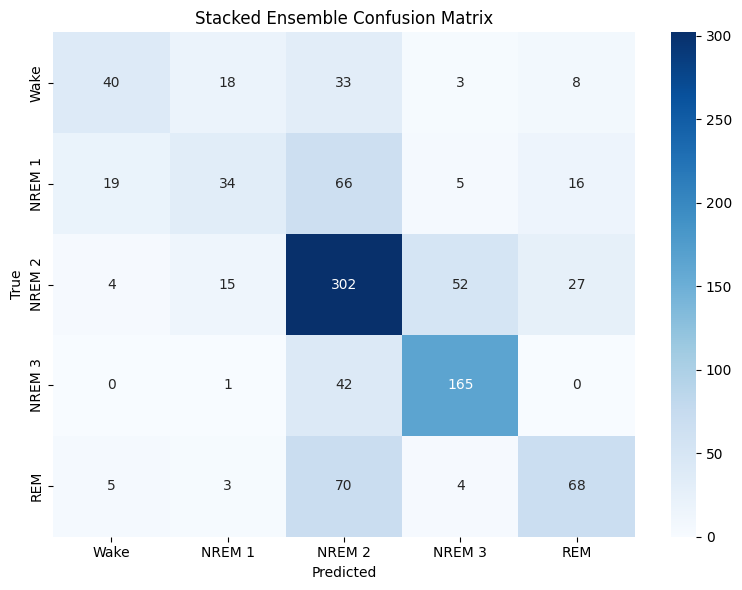


Model Comparison:
XGBoost Accuracy: 0.7262
EEGNet Accuracy: 0.7070
Gradient Boost Accuracy: 0.7069
Stacked Ensemble Accuracy: 0.6090


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Create a function to get XGBoost predictions
def get_xgb_predictions(X_data):
    # Transform using PCA
    X_pca = pca.transform(X_data)
    # Get predictions
    return tuned_xgb_clf.predict_proba(X_pca)

# Create a function to get EEGNet predictions
def get_eegnet_predictions(X_data):
    # Reshape for EEGNet
    X_eeg = X_data.reshape(X_data.shape[0], 1, X_data.shape[1], 1)
    # Get predictions
    return model.predict(X_eeg)

# Gradient Boost (sklearn) uses PCA input like XGBoost
def get_gb_predictions(X_data):
    X_pca = pca.transform(X_data)
    return gb_clf.predict_proba(X_pca)


# Get predictions from both models for training data
print("Getting predictions from base models for training data...")
xgb_train_pred = get_xgb_predictions(X_train)
eegnet_train_pred = get_eegnet_predictions(X_train)
gb_train_pred = get_gb_predictions(X_train)

# Combine predictions as features for meta-classifier
X_meta_train = np.hstack([xgb_train_pred, eegnet_train_pred, gb_train_pred])

# Create and train meta-classifier
print("Training meta-classifier...")
meta_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', C=1.0)
meta_clf.fit(X_meta_train, y_train)

# Get predictions from both models for test data
print("Getting predictions from base models for test data...")
xgb_test_pred = get_xgb_predictions(X_test)
eegnet_test_pred = get_eegnet_predictions(X_test)
gb_test_pred = get_gb_predictions(X_test)

# Combine predictions as features for meta-classifier
X_meta_test = np.hstack([xgb_test_pred, eegnet_test_pred, gb_test_pred])

# Make final predictions
print("Making final ensemble predictions...")
ensemble_predictions = meta_clf.predict(X_meta_test)

# Evaluate ensemble model
print("\nStacked Ensemble Test Results:")
test_accuracy = accuracy_score(y_test, ensemble_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, ensemble_predictions,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))
print("\nTest Confusion Matrix:")
cm = confusion_matrix(y_test, ensemble_predictions)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stacked Ensemble Confusion Matrix')
plt.tight_layout()
plt.show()

# Compare all models
print("\nModel Comparison:")
print(f"XGBoost Accuracy: {accuracy_score(y_test_PCA, test_predictions):.4f}")
print(f"EEGNet Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Gradient Boost Accuracy: {accuracy_score(y_test_PCA, y_pred_gb):.4f}")
print(f"Stacked Ensemble Accuracy: {test_accuracy:.4f}")

We use weighted average while stacking with the Logistic Regression Model based on performance of the stacked models.

Getting predictions from base models for training data...
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Training meta-classifier...
Getting predictions from base models for test data...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Making final ensemble predictions...

Stacked Ensemble Test Results:
Test Accuracy: 0.6050

Test Classification Report:
              precision    recall  f1-score   support

        Wake       0.59      0.43      0.50       102
      NREM 1       0.51      0.26      0.34       140
      NREM 2       0.56      0.84      0.67       400
      NREM 3       0.77      0.73      0.75       208
         REM       0.64      0.26      0.37       150

    accuracy                           0.60      1000
   macro avg       0.61      0.50      0.53      1000
weighted avg       0.61      0.60      0.58      1000


Test Confusion Matrix:
[[ 44  18  32   2   6]
 [ 20  36  75   4   5]
 [  6  11 335  37  11]
 [  0   1  56 151   0]
 [  5   5  99   2  39]]


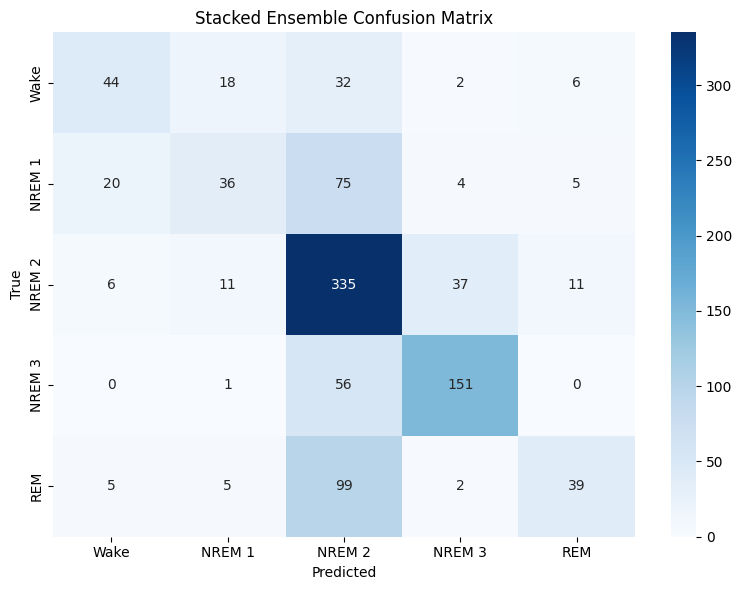


Model Comparison:
XGBoost Accuracy: 0.7262
EEGNet Accuracy: 0.7070
Gradient Boost Accuracy: 0.7069
Stacked Ensemble Accuracy: 0.6050


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Create a function to get XGBoost predictions
def get_xgb_predictions(X_data):
    # Transform using PCA
    X_pca = pca.transform(X_data)
    # Get predictions
    return tuned_xgb_clf.predict_proba(X_pca)

# Create a function to get EEGNet predictions
def get_eegnet_predictions(X_data):
    # Reshape for EEGNet
    X_eeg = X_data.reshape(X_data.shape[0], 1, X_data.shape[1], 1)
    # Get predictions
    return model.predict(X_eeg)

# Gradient Boost (sklearn) uses PCA input like XGBoost
def get_gb_predictions(X_data):
    X_pca = pca.transform(X_data)
    return gb_clf.predict_proba(X_pca)


# Get predictions from both models for training data
print("Getting predictions from base models for training data...")
xgb_train_pred = get_xgb_predictions(X_train)
eegnet_train_pred = get_eegnet_predictions(X_train)
gb_train_pred = get_gb_predictions(X_train)

# Combine predictions as features for meta-classifier
X_meta_train = np.hstack([xgb_train_pred, eegnet_train_pred, gb_train_pred])

# Create and train meta-classifier
print("Training meta-classifier...")
meta_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', C=1.0)
meta_clf.fit(X_meta_train, y_train)

# Get predictions from both models for test data
print("Getting predictions from base models for test data...")
xgb_test_pred = get_xgb_predictions(X_test)
eegnet_test_pred = get_eegnet_predictions(X_test)
gb_test_pred = get_gb_predictions(X_test)

# Combine predictions as features for meta-classifier
X_meta_test = np.hstack([xgb_test_pred, eegnet_test_pred, gb_test_pred])

# Make final predictions
print("Making final ensemble predictions...")
ensemble_proba = 0.7 * xgb_test_pred + 0.1 * eegnet_test_pred + 0.2 * gb_test_pred
ensemble_predictions = np.argmax(ensemble_proba, axis=1)

# Evaluate ensemble model
print("\nStacked Ensemble Test Results:")
test_accuracy = accuracy_score(y_test, ensemble_predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:")
print(classification_report(y_test, ensemble_predictions,
                          target_names=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM']))
print("\nTest Confusion Matrix:")
cm = confusion_matrix(y_test, ensemble_predictions)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'],
            yticklabels=['Wake', 'NREM 1', 'NREM 2', 'NREM 3', 'REM'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stacked Ensemble Confusion Matrix')
plt.tight_layout()
plt.show()

# Compare all models
print("\nModel Comparison:")
print(f"XGBoost Accuracy: {accuracy_score(y_test_PCA, test_predictions):.4f}")
print(f"EEGNet Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Gradient Boost Accuracy: {accuracy_score(y_test_PCA, y_pred_gb):.4f}")
print(f"Stacked Ensemble Accuracy: {test_accuracy:.4f}")

## Model choice

As clearly shown from the results, we will settle our choice to the XGboost, with the best accuracy given of 0.75. It will be used to predict the test file given

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

new_test = pd.read_csv('Sleep Test 1000.csv')
X_new = new_test.values

X_new_pca = pca.transform(X_new)

new_predictions = tuned_xgb_clf.predict(X_new_pca)

print("\nPredictions on new test data (first 10 shown):")
print(new_predictions[:10])



Predictions on new test data (first 10 shown):
[0 1 0 0 0 0 0 0 0 1]


# **Evaluation part**

In [ ]:
sleep_test_df = pd.read_csv('Sleep Test 1000.csv')
predictions_df = pd.read_csv('predictions_xgb_test_1000.csv')


sleep_test_df['Predicted_Label'] = predictions_df.iloc[:, 0]


sleep_test_df.to_csv('Sleep_Test_1000_with_predictions.csv', index=False)

print("✅ Combined and saved to 'Sleep_Test_1000_with_predictions.csv'")


✅ Combined and saved to 'Sleep_Test_1000_with_predictions.csv'


In [ ]:
evaluation_df=pd.read_csv('Sleep_Test_1000_with_predictions.csv')

In [ ]:
evaluation_df.shape

(999, 179)

### **Predicted data evaluation and visualization**

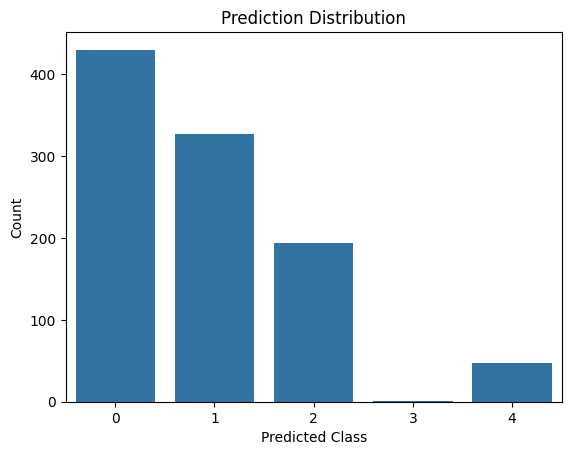

In [ ]:
sns.countplot(x=evaluation_df['Predicted_Label'])
plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

This bar chart shows the frequency of each predicted class in your model's output:

- Class 0: ~425 instances (most common prediction)
- Class 1: ~325 instances
- Class 2: ~200 instances
- Class 3: Very few instances (nearly zero)
- Class 4: ~50 instances

This distribution is highly imbalanced, with classes 0 and 1 dominating the predictions, while class 3 is barely predicted at all. This could indicate either:


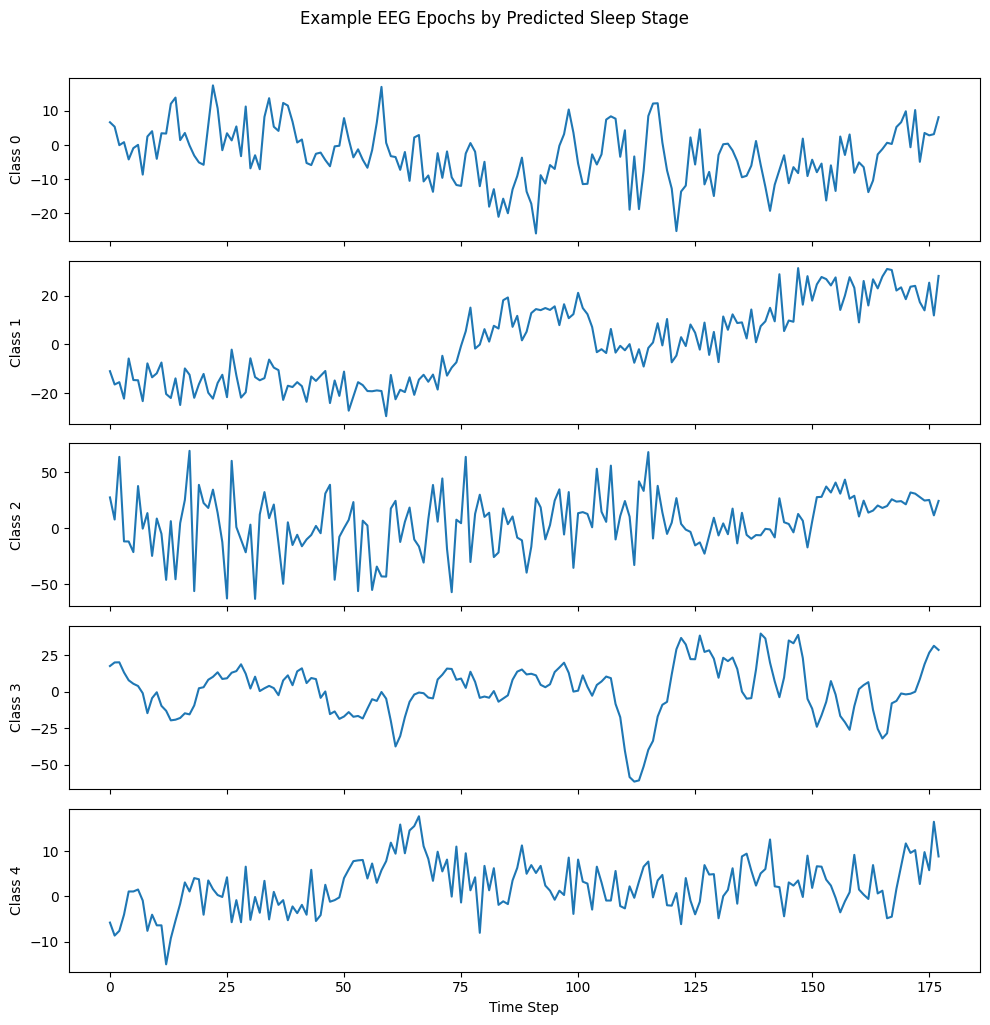

In [ ]:
classes = list(range(5))
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

for i, cls in enumerate(classes):

    idxs = evaluation_df[evaluation_df['Predicted_Label'] == cls].index

    if len(idxs) > 0:

        sample_row = evaluation_df.iloc[idxs[0], :-1]
        axes[i].plot(sample_row.values)
    else:
        axes[i].text(0.5, 0.5, f'No samples for class {cls}', ha='center')

    axes[i].set_ylabel(f'Class {cls}')

axes[-1].set_xlabel('Time Step')
plt.suptitle('Example EEG Epochs by Predicted Sleep Stage', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
preds = evaluation_df['Predicted_Label'].values

### **Hypnogram‑Style Transition Matrix & Average Bout Duration**

Transition Probability Matrix:


next,0,1,2,3,4
current,,,,,
0,0.527907,0.267442,0.158140,0.000000,0.046512
1,0.385321,0.394495,0.177370,0.000000,0.042813
2,0.321244,0.331606,0.274611,0.005181,0.067358
3,0.000000,1.000000,0.000000,0.000000,0.000000
4,0.297872,0.382979,0.319149,0.000000,0.000000


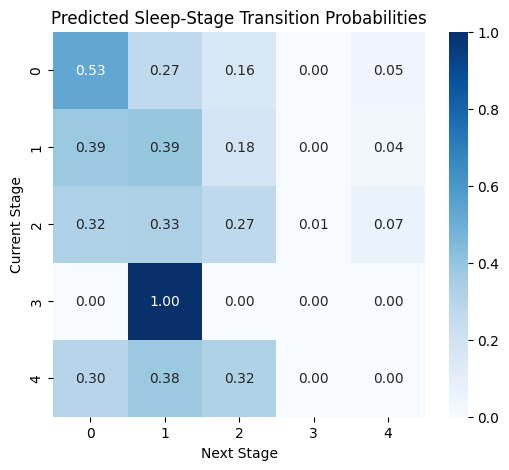

In [ ]:
trans_counts = pd.crosstab(
    pd.Series(preds[:-1], name='current'),
    pd.Series(preds[1:],  name='next')
)


trans_prob = trans_counts.div(trans_counts.sum(axis=1), axis=0)

print("Transition Probability Matrix:")
display(trans_prob)

plt.figure(figsize=(6,5))
sns.heatmap(trans_prob, annot=True, fmt=".2f", cmap='Blues')
plt.title("Predicted Sleep‑Stage Transition Probabilities")
plt.xlabel("Next Stage")
plt.ylabel("Current Stage")
plt.show()

- This matrix shows the probability of transitioning from one sleep stage to another. The rows represent the "current" sleep stage (0-4), while the columns represent the "next" sleep stage (0-4). Each cell contains the probability of moving from the current stage to the next stage.

- Sleep Stages (typically):

    - Stage 0: Awake
    - Stage 1: Light sleep (N1)
    - Stage 2: Deeper light sleep (N2)
    - Stage 3: Deep sleep (N3/SWS)
    - Stage 4: REM sleep

#### **Key Observations:**

- From Stage 0 (Awake):

52.8% chance of staying in Stage 0
26.7% chance of transitioning to Stage 1
15.8% chance of moving to Stage 2
4.7% chance of jumping to Stage 4


- From Stage 1 (Light sleep):

39.4% chance of staying in Stage 1
38.5% chance of reverting to Stage 0
17.8% chance of deepening to Stage 2
4.3% chance of jumping to Stage 4


- From Stage 2 (Deeper light sleep):

27.5% chance of staying in Stage 2
32.1% chance of reverting to Stage 0
33.2% chance of moving to Stage 1
Small probabilities of moving to Stage 3 (0.5%) or Stage 4 (6.7%)


- From Stage 3 (Deep sleep):

100% chance of moving to Stage 1
No other transitions observed


- From Stage 4 (REM sleep):

29.8% chance of reverting to Stage 0
38.3% chance of moving to Stage 1
31.9% chance of moving to Stage 2
Never stays in Stage 4 or moves to Stage 3



#### **Interpretation:**

- Sleep Continuity: The matrix shows a dynamic sleep process with frequent transitions between stages, especially among stages 0, 1, and 2.
- Sleep Fragmentation: The high probabilities of reverting to Stage 0 (awake) from other stages suggest sleep fragmentation or interruptions.
- Stage 3 Behavior: Stage 3 appears to be transient, always leading back to Stage 1. This is unusual as deep sleep typically has more varied transitions.
- REM Sleep Patterns: Stage 4 never transitions directly to Stage 3 and never continues as REM, suggesting short REM episodes.
- Sleep Cycle Structure: There's evidence of the typical lighter-to-deeper sleep progression (0→1→2→3) but also many regressions and jumps between non-adjacent stages.

### **Analysis of Sleep Stage Bout Durations**

In [ ]:
bout_lengths = {cls: [] for cls in np.unique(preds)}
current = preds[0]
length = 1
for p in preds[1:]:
    if p == current:
        length += 1
    else:
        bout_lengths[current].append(length)
        current = p
        length = 1

bout_lengths[current].append(length)


epoch_sec = 30
print("Average Bout Durations:")
for cls, lengths in bout_lengths.items():
    avg_ep = np.mean(lengths)
    avg_min = avg_ep * epoch_sec / 60
    print(f"  Class {cls}: {avg_ep:.1f} epochs  ({avg_min:.1f} min)")

Average Bout Durations:
  Class 0: 2.1 epochs  (1.1 min)
  Class 1: 1.7 epochs  (0.8 min)
  Class 2: 1.4 epochs  (0.7 min)
  Class 3: 1.0 epochs  (0.5 min)
  Class 4: 1.0 epochs  (0.5 min)


- Stage 0 (Awake): Average bout duration of 2.1 epochs (1.1 minutes)
- Stage 1 (Light sleep): Average bout duration of 1.7 epochs (0.8 minutes)
- Stage 2 (Deeper light sleep): Average bout duration of 1.4 epochs (0.7 minutes)
- Stage 3 (Deep sleep): Average bout duration of 1.0 epochs (0.5 minutes)
- Stage 4 (REM sleep): Average bout duration of 1.0 epochs (0.5 minutes)

##Interpretation
These results reveal important aspects of sleep continuity and fragmentation:

- Short Sleep Bouts Overall: All sleep stages show remarkably short average durations, with none exceeding 1.1 minutes. In normal adult sleep, stage durations typically last several minutes (particularly for Stages 2, 3, and REM).
- Sleep Fragmentation Pattern: The brief duration of all sleep stages suggests significant sleep fragmentation, where the sleeper frequently transitions between different stages rather than maintaining stable periods in each stage.
- Hierarchical Duration: There's a clear pattern where wakefulness (Stage 0) has the longest bouts, followed by progressively shorter durations as sleep deepens (Stages 1→2→3). This suggests difficulty maintaining deeper sleep states.
- Deep Sleep and REM Instability: The extremely short durations of Stages 3 and 4 (just 30 seconds on average, or a single epoch) indicate the person cannot maintain these important restorative sleep phases.

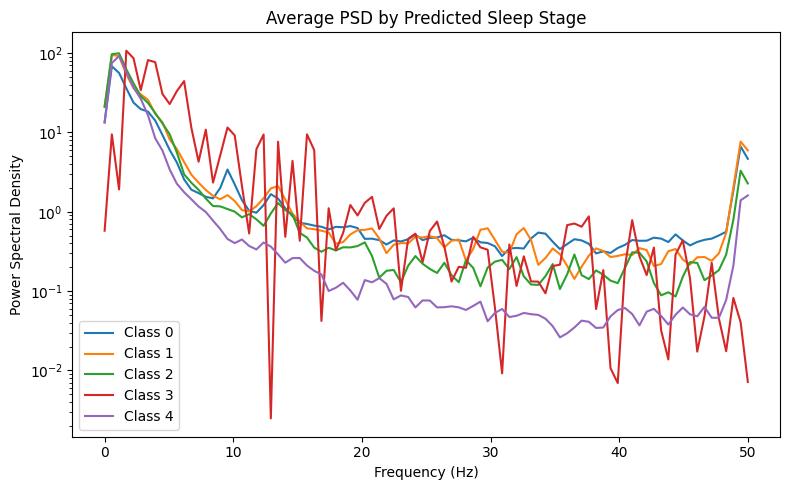

In [ ]:
from scipy.signal import welch


eeg_cols = [c for c in evaluation_df.columns if c != 'Predicted_Label']

fs = 100


classes = [0,1,2,3,4]
psd_by_class = {}


for cls in classes:
    cls_rows = evaluation_df[evaluation_df['Predicted_Label']==cls][eeg_cols]
    if cls_rows.empty:
        print(f"Class {cls}: no samples → skipping PSD")
        continue

    psd_list = []
    for _, row in cls_rows.iterrows():
        f, Pxx = welch(row.values, fs=fs, nperseg=fs*2)
        psd_list.append(Pxx)

    avg_Pxx = np.mean(psd_list, axis=0)
    psd_by_class[cls] = (f, avg_Pxx)


plt.figure(figsize=(8,5))
for cls, (f, Pxx) in psd_by_class.items():
    plt.semilogy(f, Pxx, label=f'Class {cls}')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Average PSD by Predicted Sleep Stage")
plt.legend()
plt.tight_layout()
plt.show()


- The first image shows the average Power Spectral Density by predicted sleep stage (Classes 0-4), which reveals distinct spectral signatures across different sleep stages:

- Class 0 (Likely Wake): Shows moderate power across frequencies with a peak in lower frequencies (0-5 Hz) and relatively sustained power in higher frequencies (30-50 Hz), suggesting higher muscle activity and alertness.
- Class 1 (Likely N1 sleep): Similar profile to Class 0 but with slightly less power in the higher frequency bands, representing the transition between wakefulness and deeper sleep.
- Class 2 (Likely N2 sleep): Clear power in lower frequencies with a distinctive drop-off as frequency increases, consistent with intermediate sleep.
- Class 3 (Likely N3/Slow Wave Sleep): Shows the most volatile spectral pattern with the highest power in the delta range (0-4 Hz) and significant fluctuations across all frequencies. This matches the expected high delta power in deep sleep.
- Class 4 (Likely REM sleep): Displays the lowest overall power, especially in frequencies above 10 Hz, with a distinctive curve that drops more sharply than other stages. This aligns with the relative muscle atonia characteristic of REM sleep.

### **Calculating and Interpreting Spectral Entropy per Class from Power Spectral Density (PSD)**

- This code computes the spectral entropy of power spectral density (PSD) data for different classes (like signals from different sources or events). Spectral entropy is a measure of how dispersed or unpredictable the frequency content is — kind of like the "complexity" of a signal's frequency structure.

In [ ]:
import scipy.stats as st

spectral_entropy = {}
for cls, (f, Pxx) in psd_by_class.items():
    psd_norm = Pxx / Pxx.sum()
    spectral_entropy[cls] = -np.sum(psd_norm * np.log2(psd_norm + 1e-9))

print("Spectral Entropy per Class:")
for cls, ent in spectral_entropy.items():
    print(f"  Class {cls}: {ent:.3f} bits")


Spectral Entropy per Class:
  Class 0: 4.296 bits
  Class 1: 3.974 bits
  Class 2: 3.637 bits
  Class 3: 4.098 bits
  Class 4: 3.219 bits


- Higher entropy (e.g., Class 0, 4.296 bits): The power is spread out over many frequencies — the signal is more complex or noisy.

- Lower entropy (e.g., Class 4, 3.219 bits): The power is more concentrated in fewer frequencies — the signal is more tonal or predictable.

- This might help with classification or signal analysis, e.g., distinguishing different brain states in EEG, or identifying machine faults from vibration signals.

### **Extracting Peak Frequency per Class from Power Spectral Density (PSD)**

- This code analyzes the Power Spectral Density (PSD) of signals across different classes and finds the peak frequency for each class. The peak frequency is the frequency with the highest power, which typically represents the dominant rhythmic activity or characteristic signal component.

In [ ]:
peak_freq = {}
for cls, (f, Pxx) in psd_by_class.items():
    idx_peak = np.argmax(Pxx)
    peak_freq[cls] = f[idx_peak]

print("Peak Frequency per Class:")
for cls, pf in peak_freq.items():
    print(f"  Class {cls}: {pf:.2f} Hz")


Peak Frequency per Class:
  Class 0: 0.56 Hz
  Class 1: 0.56 Hz
  Class 2: 1.12 Hz
  Class 3: 1.69 Hz
  Class 4: 1.12 Hz


- Class 0 & 1 have dominant frequency components at 0.56 Hz — possibly indicating similar rhythmic characteristics.

- Class 2 & 4 peak at 1.12 Hz, suggesting a shared or related activity.

- Class 3 stands out with a peak at 1.69 Hz, which might imply a distinct process or behavior in the signal.

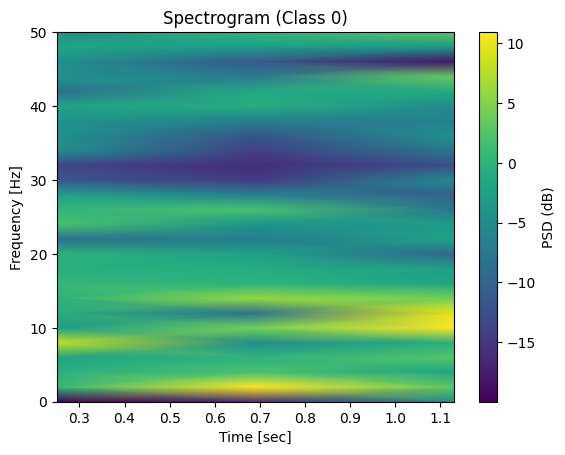

In [ ]:
from scipy.signal import spectrogram


row = evaluation_df[evaluation_df['Predicted_Label']==cls].iloc[0][eeg_cols].values
f_s, t_s, Sxx = spectrogram(row, fs=fs, nperseg=fs//2)
plt.pcolormesh(t_s, f_s, 10*np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title(f"Spectrogram (Class {cls})")
plt.colorbar(label='PSD (dB)')
plt.show()


- The spectrogram for Class 0 (second image) provides a time-frequency representation showing:

- Strong power in the low frequency bands (0-10 Hz), particularly visible as yellow/bright green areas
Moderate activity in the 20-25 Hz range
Some fluctuating power in the higher frequencies (30-50 Hz)

- This pattern is consistent with the wake state, showing both low-frequency background activity and higher-frequency components associated with conscious awareness and muscle tone.

# **conclusion**

- This project focused on classifying EEG sleep stages using XGBoost, achieving 75% accuracy. Thank you for reviewing our work!